<a href="https://colab.research.google.com/github/rafaelhasslocher/predicao-avc/blob/master/MVP_Predicao_AVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **MVP - Dados de Predição para Ocorrência de AVCs**

**Nome:** Rafael Hasslocher de Oliveira Lima

**Matrícula:** 4052024002344

**Dataset utilizado:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset).

### **1. Descrição do Problema**

#### **1.1. Contexto Geral**

O Brasil atravessa, atualmente, uma crise silenciosa de saúde pública. Segundo o Conselho Federal de Farmácia, em [artigo de março/2026](https://site.cff.org.br/noticia/Noticias-gerais/20/03/2026/avc-avanca-no-brasil-e-ja-mata-mais-que-infarto-com-uma-morte-a-cada-seis-minutos), um brasileiro faleceu a cada seis minutos em decorrência de um Acidente Vascular Cerebral (AVC) entre janeiro e outubro de 2025, superando inclusive o infarto. Essa condição médica, caracterizada pelo entupimento (AVC isquêmico) ou rompimento (AVC hemorrágico) de vasos que levam sangue ao cérebro, pode ter consequências graves e irreversíveis: além do risco de morte, os pacientes sobreviventes frequentemente desenvolvem sequelas cognitivas, dificuldades de fala ou locomoção e paralisia total ou parcial, impactando profundamente sua qualidade de vida e a de seus familiares.

O cenário é ainda mais preocupante quando observado sob uma perspectiva global. De acordo com a [Organização Mundial da Saúde (OMS)](https://www.who.int/news-room/fact-sheets/detail/the-top-10-causes-of-death), o AVC figura entre as três principais causas de morte no mundo. No Brasil, a situação é agravada pela desigualdade no acesso à saúde e pelo diagnóstico tardio, que reduzem significativamente as chances de um tratamento eficaz.

Cabe pontuar, no entanto, que a Medicina afirma que o AVC é, em grande medida, evitável. A prevenção envolve medidas acessíveis e eficazes, como manter a pressão arterial sob controle, adotar uma alimentação equilibrada, praticar atividade física regularmente, evitar o tabagismo e o consumo excessivo de álcool, além de realizar acompanhamento médico periódico. De acordo com o [Ministério da Saúde](https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/a/avc), os principais fatores de risco incluem hipertensão arterial, diabetes, obesidade, colesterol elevado, sedentarismo e tabagismo, sendo a maioria deles modificável com mudanças de hábito e tratamento adequado.

Nesse contexto, as ferramentas de análise de dados podem se tornar poderosas aliadas à medicina preventiva. A identificação de padrões em dados clínicos permite antecipar casos em populações de maior risco e orientar políticas de saúde pública de maneira mais precisa. Diante desse cenário, o presente trabalho busca utilizar a análise e a visualização de dados para trazer insights que ajudem a responder hipóteses relacionadas aos principais fatores de risco da ocorrência de um AVC.

### **1.2. Hipóteses Propostas**

Com base no consenso médico sobre a ocorrência de um AVC, traçamos as seguintes hipóteses a serem verificadas durante a análise:

- **Hipótese 1:** Pacientes mais velhos apresentam maior probabilidade de AVC, uma vez que o envelhecimento é reconhecido como um dos principais fatores de risco;
- **Hipótese 2:** A presença de hipertensão e/ou doença cardíaca está associada a uma maior taxa de ocorrência de AVC;
- **Hipótese 3:** Pacientes com nível de glicemia média elevado (indicativo de diabetes) apresentam maior incidência de AVC;
- **Hipótese 4:** O hábito de fumar (incluindo ex-fumantes) está associado a uma maior taxa de AVC em comparação a não-fumantes;
- **Hipótese 5:** O IMC elevado (acima de 30, indicativo de obesidade) está correlacionado com maior risco de AVC.

### **1.3. Tipo de Problema**

Trata-se de um problema de **aprendizado supervisionado de classificação binária**: a variável-resposta `avc` assume o valor `1` quando o paciente teve AVC e `0` caso contrário.

### **1.4. Dados utilizados**

Para o desenvolvimento deste trabalho, utilizou-se a base [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) do Kaggle. Na seção 'Acknowledgements', o autor indica que a base destina-se a fins educacionais e solicita que seja devidamente creditado em caso de uso, condição atendida neste trabalho.

### **1.5. Atributos do Dataset**

A tabela abaixo detalha os atributos do dataset escolhido para o desenvolvimento desse trabalho, conforme descritivo no link de origem dos dados no Kaggle. Com o objetivo de facilitar a referência ao longo do código, optamos por traduzir os nomes de cada atributo (seção 2.3), conforme detalhamento a seguir:

| Atributo - Nome Original | Atributo - Nome Traduzido | Descrição |
|:------------------------:|:-------------------------:|:---------:|
| `id` | `id` | Identificador único |
| `gender` | `genero` | Gênero: `Male`, `Female`, `Other` |
| `age` | `idade` | Idade do paciente |
| `hypertension` | `hipertensao` | `0` se o paciente não possui hipertensão, `1` se o paciente possui hipertensão |
| `heart_disease` | `doenca_cardiaca` | `0` se o paciente não apresenta doença cardíaca, `1` se o paciente apresenta doença cardíaca |
| `ever_married` | `casado` | Estado civil: `Yes` se o paciente for casado, `No` se o paciente não for casado |
| `work_type` | `tipo_emprego` | Tipo de trabalho: `children`, `Govt_job`, `Never_worked`, `Private`, `Self-employed` |
| `Residence_type` | `tipo_residencia` | Tipo de residência: `Urban` / `Rural` |
| `avg_glucose_level` | `glicemia_media` | Nível médio de glicose no sangue |
| `bmi` | `imc` | Índice de Massa Corporal (IMC) |
| `smoking_status` | `fumante` | Tabagismo: `formerly smoked`, `never smoked`, `smokes`, `Unknown` |
| `stroke` | `avc` | **variável resposta**: `0` se o paciente não teve AVC, `1` se o paciente teve AVC |

## **2. Análise Exploratória de Dados**

### **2.1. Importação de Bibliotecas e do Dataset**

Inicialmente, importam-se as bibliotecas necessárias para a análise e carrega-se o dataset diretamente do repositório público no GitHub.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency, pointbiserialr
from tabulate import tabulate
from sklearn.preprocessing import OneHotEncoder


URL_DATASET = "https://raw.githubusercontent.com/rafaelhasslocher/predicao-avc/refs/heads/master/data/healthcare-dataset-stroke-data.csv"

df_avc_bruto = pd.read_csv(URL_DATASET)

### **2.2. Dimensões do Dataset**

Para iniciarmos a análise das informações disponíveis, verificamos quantos atributos e quantas instâncias temos disponíveis.

In [2]:
n_linhas, n_colunas = df_avc_bruto.shape
print(
    f"O dataset escolhido apresenta {n_linhas} instâncias (linhas) e {n_colunas} atributos (colunas)."
)

O dataset escolhido apresenta 5110 instâncias (linhas) e 12 atributos (colunas).


Com 5.110 instâncias e 10 atributos preditores além da variável resposta (`avc`) e da coluna de identificação (`id`), a base apresenta volume suficiente para a análise exploratória e o desenvolvimento dos modelos propostos.

### **2.3. Tipos de Dados por Atributo e Visualização do Dataset**

Verificamos abaixo a distribuição dos tipos de dados para cada atributo. Nessa etapa, descartaremos o atributo `id`, que é um identificador de linha sem valor preditivo.

In [3]:
# Mapeamento de tradução das colunas

MAPA_RENOMEACAO = {
    "gender": "genero",
    "age": "idade",
    "hypertension": "hipertensao",
    "heart_disease": "doenca_cardiaca",
    "ever_married": "casado",
    "work_type": "tipo_emprego",
    "Residence_type": "tipo_residencia",
    "avg_glucose_level": "glicemia_media",
    "bmi": "imc",
    "smoking_status": "fumante",
    "stroke": "avc",
}

# Remove o identificador sem valor preditivo e renomeia as colunas

df_avc = df_avc_bruto.drop(columns=["id"]).rename(columns=MAPA_RENOMEACAO)

df_tipos = (
    df_avc.dtypes.rename("Tipo").reset_index().rename(columns={"index": "Atributo"})
)

print(
    tabulate(
        df_tipos.values.tolist(),
        headers=df_tipos.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_tipos.columns),
    )
)

╒═════════════════╤═════════╕
│    Atributo     │  Tipo   │
╞═════════════════╪═════════╡
│     genero      │   str   │
├─────────────────┼─────────┤
│      idade      │ float64 │
├─────────────────┼─────────┤
│   hipertensao   │  int64  │
├─────────────────┼─────────┤
│ doenca_cardiaca │  int64  │
├─────────────────┼─────────┤
│     casado      │   str   │
├─────────────────┼─────────┤
│  tipo_emprego   │   str   │
├─────────────────┼─────────┤
│ tipo_residencia │   str   │
├─────────────────┼─────────┤
│ glicemia_media  │ float64 │
├─────────────────┼─────────┤
│       imc       │ float64 │
├─────────────────┼─────────┤
│     fumante     │   str   │
├─────────────────┼─────────┤
│       avc       │  int64  │
╘═════════════════╧═════════╛


A seguir, vamos verificar as primeiras 5 linhas do dataset.

In [4]:
print(
    tabulate(
        df_avc.head(5).values.tolist(),
        headers=df_avc.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_avc.columns),
    )
)

╒══════════╤═════════╤═══════════════╤═══════════════════╤══════════╤════════════════╤═══════════════════╤══════════════════╤═══════╤═════════════════╤═══════╕
│  genero  │  idade  │  hipertensao  │  doenca_cardiaca  │  casado  │  tipo_emprego  │  tipo_residencia  │  glicemia_media  │  imc  │     fumante     │  avc  │
╞══════════╪═════════╪═══════════════╪═══════════════════╪══════════╪════════════════╪═══════════════════╪══════════════════╪═══════╪═════════════════╪═══════╡
│   Male   │   67    │       0       │         1         │   Yes    │    Private     │       Urban       │      228.69      │ 36.6  │ formerly smoked │   1   │
├──────────┼─────────┼───────────────┼───────────────────┼──────────┼────────────────┼───────────────────┼──────────────────┼───────┼─────────────────┼───────┤
│  Female  │   61    │       0       │         0         │   Yes    │ Self-employed  │       Rural       │      202.21      │  nan  │  never smoked   │   1   │
├──────────┼─────────┼───────────────┼──

É possível verificar já na tabela acima que o atributo `imc` apresenta valores nulos. A seguir, verificaremos quais outros atributos podem apresentar esse mesmo problema.

### **2.4. Verificação de Valores Nulos**

In [5]:
contagem_nulos = df_avc.isnull().sum()
perc_nulos = (contagem_nulos / len(df_avc) * 100).round(2)

df_nulos = (
    pd.DataFrame({"Qtd Faltante": contagem_nulos, "% Faltante": perc_nulos})
    .reset_index()
    .rename(columns={"index": "Atributo"})
)
df_nulos_filtrado = df_nulos[df_nulos["Qtd Faltante"] > 0]

if df_nulos_filtrado.empty:
    print("Nenhum valor faltante encontrado.")
else:
    print("Atributos com valores faltantes:")
    print(
        tabulate(
            df_nulos_filtrado.values.tolist(),
            headers=df_nulos_filtrado.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * len(df_nulos_filtrado.columns),
        )
    )

Atributos com valores faltantes:
╒════════════╤════════════════╤══════════════╕
│  Atributo  │  Qtd Faltante  │  % Faltante  │
╞════════════╪════════════════╪══════════════╡
│    imc     │      201       │     3.93     │
╘════════════╧════════════════╧══════════════╛


Somente o campo `imc` apresenta valores nulos, totalizando 201 registros (aprox. 4% do total). Para decidir a estratégia de tratamento mais adequada, é necessário analisarmos se essa ausência ocorre de forma aleatória ou de forma sistemática, potencialmente correlacionada com a variável-resposta `avc`.

A análise a seguir cruza a presença de valores nulos de `imc` com a distribuição da variável `avc`, de modo a avaliar se há uma concentração desproporcional de nulos entre pacientes que apresentaram ou não AVC.

In [6]:
colunas_com_nulos = df_nulos_filtrado["Atributo"].tolist()

for coluna in colunas_com_nulos:
    df_aux = df_avc[[coluna, "avc"]].copy()
    df_aux["eh_nulo"] = df_aux[coluna].isnull()

    tabela_cruzada = (
        pd.crosstab(df_aux["eh_nulo"], df_aux["avc"], normalize="index") * 100
    ).round(2)

    tabela_cruzada.index = tabela_cruzada.index.map({False: "Não", True: "Sim"})
    tabela_cruzada = tabela_cruzada.reset_index().rename(
        columns={"eh_nulo": "Valor nulo?", 0: "Sem AVC (%)", 1: "Com AVC (%)"}
    )

    print(f"\nDistribuição de nulos em '{coluna}':")
    print(
        tabulate(
            tabela_cruzada.values.tolist(),
            headers=tabela_cruzada.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * 3,
        )
    )


Distribuição de nulos em 'imc':
╒═══════════════╤═══════════════╤═══════════════╕
│  Valor nulo?  │  Sem AVC (%)  │  Com AVC (%)  │
╞═══════════════╪═══════════════╪═══════════════╡
│      Não      │     95.74     │     4.26      │
├───────────────┼───────────────┼───────────────┤
│      Sim      │     80.1      │     19.9      │
╘═══════════════╧═══════════════╧═══════════════╛


Conforme pode ser verificado acima, os registros de IMC nulo apresentam quase cinco vezes mais casos de AVC do que os registros não-nulos (4,3% contra 19,9%). Trata-se de indicativo de que os valores ausentes de IMC não são aleatórios: parece haver uma associação entre a ausência do campo `imc` e a ocorrência de AVC.

Por essa razão, a simples remoção das linhas com IMC nulo pode não ser o melhor caminho: ao excluir esses registros, retiraríamos uma parcela desproporcional de casos positivos (AVC = 1), agravando ainda mais o desbalanceamento do dataset. Optou-se, portanto, pela substituição desses valores pela mediana estratificada dos dados de IMC, pelos seguintes motivos:

- A mediana é robusta frente a outliers, evitando distorção relevante da análise;

- A estratificação pelo campo `avc` preserva as diferenças de distribuição entre as classes, evitando que a substituição impacte artificialmente as distinções entre pacientes com e sem AVC.

In [7]:
# Imputação da mediana de 'imc' estratificada pela classe 'avc'

df_avc["imc"] = df_avc.groupby("avc")["imc"].transform(lambda x: x.fillna(x.median()))

### **2.5. Valores Únicos e Distribuição por Atributo**

A seguir, verificaremos os valores únicos e a distribuição por atributo em todas as colunas do conjunto de dados. O objetivo é identificar a representatividade de cada categoria, detectar possíveis inconsistências de codificação e avaliar o grau de desbalanceamento entre classes ou faixas de valores, informações que servirão de base para as transformações necessárias na etapa de pré‑processamento.

Inicialmente, separaremos as colunas por tipo para facilitar a referência futura no código.

In [8]:
# Definição das listas de colunas por tipo, conforme verificado acima

COLUNAS_BINARIAS = ["hipertensao", "doenca_cardiaca", "avc"]
COLUNAS_CATEGORICAS = ["genero", "casado", "tipo_emprego", "tipo_residencia", "fumante"]
COLUNAS_CONTINUAS = ["idade", "glicemia_media", "imc"]

#### **2.5.1. Atributos Binários**

In [9]:
def resumir_coluna_binaria(df, coluna):

    contagem = df[coluna].value_counts()
    percentual = (df[coluna].value_counts(normalize=True) * 100).round(2)

    df_resumo = pd.DataFrame({"Contagem": contagem, "%": percentual}).reset_index()
    df_resumo.columns = [coluna, "Contagem", "%"]
    df_resumo["Contagem"] = df_resumo["Contagem"].apply(
        lambda x: f"{x:,}".replace(",", ".")
    )

    print(f"\nAtributo: {coluna}")
    print(
        tabulate(
            df_resumo.values.tolist(),
            headers=df_resumo.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * len(df_resumo.columns),
        )
    )


for col in COLUNAS_BINARIAS:
    resumir_coluna_binaria(df_avc, col)


Atributo: hipertensao
╒═══════════════╤════════════╤═══════╕
│  hipertensao  │  Contagem  │   %   │
╞═══════════════╪════════════╪═══════╡
│       0       │   4.612    │ 90.25 │
├───────────────┼────────────┼───────┤
│       1       │    498     │ 9.75  │
╘═══════════════╧════════════╧═══════╛

Atributo: doenca_cardiaca
╒═══════════════════╤════════════╤══════╕
│  doenca_cardiaca  │  Contagem  │  %   │
╞═══════════════════╪════════════╪══════╡
│         0         │   4.834    │ 94.6 │
├───────────────────┼────────────┼──────┤
│         1         │    276     │ 5.4  │
╘═══════════════════╧════════════╧══════╛

Atributo: avc
╒═══════╤════════════╤═══════╕
│  avc  │  Contagem  │   %   │
╞═══════╪════════════╪═══════╡
│   0   │   4.861    │ 95.13 │
├───────┼────────────┼───────┤
│   1   │    249     │ 4.87  │
╘═══════╧════════════╧═══════╛


Com base nas tabelas acima, levantam-se os seguintes pontos em relação aos atributos binários:

- **Atributo `avc` (variável resposta):** O dataset apresenta um desbalanceamento significativo de classes: apenas 4,9% dos pacientes (249 casos) apresentaram AVC. Esse desequilíbrio é esperado, dado que a ocorrência de um AVC é relativamente rara em relação à população geral. Esse ponto pode, no entanto, levar modelos preditivos a privilegiar a classe majoritária em nome da acurácia, de modo que será necessário endereçar esse ponto na etapa de pré-processamento.

- **Atributo `hipertensao`:** Apenas 9,8% dos pacientes apresentam hipertensão. Apesar da baixa prevalência, essa condição é comumente associada à ocorrência de AVCs, o que torna relevante analisar sua relação com a variável resposta nas etapas seguintes.

- **Atributo `doenca_cardiaca`:** De maneira semelhante, temos um atributo com baixa prevalência de ocorrências, mas geralmente associado à ocorrência de AVCs.

#### **2.5.2. Atributos Categóricos**

In [10]:
def resumir_coluna_categorica(df, coluna):

    df_resumo = df[coluna].value_counts().reset_index()
    df_resumo.columns = [coluna, "contagem"]
    df_resumo["percentual"] = (
        df_resumo["contagem"] / df_resumo["contagem"].sum() * 100
    ).round(2)
    df_resumo["contagem"] = df_resumo["contagem"].apply(
        lambda x: f"{x:,}".replace(",", ".")
    )
    df_resumo["percentual"] = df_resumo["percentual"].apply(lambda x: f"{x:.2f}%")

    n_categorias = len(df_resumo)
    print(f"\nAtributo: {coluna} ({n_categorias} categorias)")
    print(
        tabulate(
            df_resumo.values.tolist(),
            headers=df_resumo.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * len(df_resumo.columns),
        )
    )


for col in COLUNAS_CATEGORICAS:
    resumir_coluna_categorica(df_avc, col)


Atributo: genero (3 categorias)
╒══════════╤════════════╤══════════════╕
│  genero  │  contagem  │  percentual  │
╞══════════╪════════════╪══════════════╡
│  Female  │   2.994    │    58.59%    │
├──────────┼────────────┼──────────────┤
│   Male   │   2.115    │    41.39%    │
├──────────┼────────────┼──────────────┤
│  Other   │     1      │    0.02%     │
╘══════════╧════════════╧══════════════╛

Atributo: casado (2 categorias)
╒══════════╤════════════╤══════════════╕
│  casado  │  contagem  │  percentual  │
╞══════════╪════════════╪══════════════╡
│   Yes    │   3.353    │    65.62%    │
├──────────┼────────────┼──────────────┤
│    No    │   1.757    │    34.38%    │
╘══════════╧════════════╧══════════════╛

Atributo: tipo_emprego (5 categorias)
╒════════════════╤════════════╤══════════════╕
│  tipo_emprego  │  contagem  │  percentual  │
╞════════════════╪════════════╪══════════════╡
│    Private     │   2.925    │    57.24%    │
├────────────────┼────────────┼──────────────┤
│ Se

A análise dos atributos categóricos indica os seguintes pontos relevantes:

- **Atributo `genero`:** O dataset é composto por aproximadamente 59% de mulheres e 41% de homens. Chama a atenção a categoria `Other`, com apenas 1 instância, representatividade insuficiente para qualquer análise isolada. Desse modo, optamos por substituir essa instância pela moda do atributo (`Female`).

- **Atributo `casado`:** Há prevalência de pacientes casados no dataset, o que pode indicar parcialmente a composição etária dos dados: pessoas mais velhas tendem a ser casadas com maior frequência em relação aos jovens.

- **Atributo `tipo_emprego`:** A categoria dominante é `Private`, com aproximadamente 57% dos casos. A baixa ocorrência de `children` reforça que a amostra é composta predominantemente por adultos.

- **Atributo `tipo_residencia`:** Distribuição equilibrada entre `Urban` e `Rural`, sem grandes assimetrias.

- **Atributo `fumante`:** Destaca-se a forte presença de `Unknown`, com aproximadamente 30% dos registros originais, uma forma de dado ausente implícita que merecerá atenção especial nas próximas etapas.

Cabe pontuar que, após a substituição da instância `Other` pela moda, três atributos categóricos passam a ter exatamente duas categorias, permitindo a aplicação direta de codificação binária (Label Encoding). Optamos por já efetuar essa transformação, de modo a permitir a análise da correlação entre esses atributos na etapa de visualização. A máscara de codificação adotada é:

| Atributo | Máscara |
|:------------:|:-----------:|
|`genero`|`0: Female; 1: Male`|
|`casado`|`0: No; 1: Yes`|
|`tipo_residencia`|`0: Rural; 1: Urban`|

Aplicou-se, ainda, a tradução das categorias das variáveis `fumante` e `tipo_emprego`, de modo a facilitar a referência ao longo do código, conforme tabela a seguir:

| Atributo | Valor Original | Valor Traduzido |
|:---:|:---:|:---:|
| `fumante` | `never smoked` | `Não-fumante` |
| `fumante` | `formerly smoked` | `Ex-fumante` |
| `fumante` | `smokes` | `Fumante` |
| `fumante` | `Unknown` | `Desconhecido` |
| `tipo_emprego` | `Govt_job` | `Cargo Público` |
| `tipo_emprego` | `Self-employed` | `Autônomo` |
| `tipo_emprego` | `Private` | `Privado` |
| `tipo_emprego` | `children` | `Criança` |
| `tipo_emprego` | `Never_worked` | `Nunca trabalhou` |

In [11]:
# Substitui a única instância "Other" em 'genero' pela moda

df_avc["genero"] = df_avc["genero"].replace("Other", df_avc["genero"].mode()[0])

# Label Encoding para atributos binários (exatamente 2 categorias)

MAPA_LABEL_ENCODING = {
    "genero": {"Female": 0, "Male": 1},
    "casado": {"No": 0, "Yes": 1},
    "tipo_residencia": {"Rural": 0, "Urban": 1},
}

for coluna, mapa in MAPA_LABEL_ENCODING.items():
    df_avc[coluna] = df_avc[coluna].map(mapa)

# Atualiza as listas de controle refletindo as mudanças de tipo

COLUNAS_LABEL_ENCODED = list(MAPA_LABEL_ENCODING.keys())
COLUNAS_CATEGORICAS = [c for c in COLUNAS_CATEGORICAS if c not in COLUNAS_LABEL_ENCODED]
COLUNAS_BINARIAS = COLUNAS_BINARIAS + COLUNAS_LABEL_ENCODED

# Tradução de Variáveis Categórias

TRADUCAO_CATEGORIAS = {
    "tipo_emprego": {
        "Private": "Privado",
        "Self-employed": "Autônomo",
        "Govt_job": "Cargo Público",
        "children": "Criança",
        "Never_worked": "Nunca trabalhou",
    },
    "fumante": {
        "formerly smoked": "Ex-fumante",
        "never smoked": "Não-fumante",
        "smokes": "Fumante",
        "Unknown": "Desconhecido",
    },
}

# Traduz as categorias dos atributos tipo_emprego e fumante

for coluna, mapa in TRADUCAO_CATEGORIAS.items():
    df_avc[coluna] = df_avc[coluna].map(mapa)

print(
    tabulate(
        df_avc.head(5).values.tolist(),
        headers=df_avc.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_avc.columns),
    )
)

╒══════════╤═════════╤═══════════════╤═══════════════════╤══════════╤════════════════╤═══════════════════╤══════════════════╤═══════╤═════════════╤═══════╕
│  genero  │  idade  │  hipertensao  │  doenca_cardiaca  │  casado  │  tipo_emprego  │  tipo_residencia  │  glicemia_media  │  imc  │   fumante   │  avc  │
╞══════════╪═════════╪═══════════════╪═══════════════════╪══════════╪════════════════╪═══════════════════╪══════════════════╪═══════╪═════════════╪═══════╡
│    1     │   67    │       0       │         1         │    1     │    Privado     │         1         │      228.69      │ 36.6  │ Ex-fumante  │   1   │
├──────────┼─────────┼───────────────┼───────────────────┼──────────┼────────────────┼───────────────────┼──────────────────┼───────┼─────────────┼───────┤
│    0     │   61    │       0       │         0         │    1     │    Autônomo    │         0         │      202.21      │ 29.7  │ Não-fumante │   1   │
├──────────┼─────────┼───────────────┼───────────────────┼──────

#### **2.5.3. Atributos Numéricos Contínuos**

A seguir, calculamos um resumo estatístico dos atributos numéricos contínuos do dataset: mínimo, máximo, mediana, média, desvio-padrão, moda e número de valores ausentes. Esse resumo orienta a identificação de assimetrias, outliers e a necessidade de transformações como normalização ou padronização.

In [12]:
df_resumo_estatistico = (
    df_avc[COLUNAS_CONTINUAS].agg(["min", "max", "median", "mean", "std"]).round(2)
)
df_resumo_estatistico.loc["moda"] = df_avc[COLUNAS_CONTINUAS].mode().iloc[0].round(2)
df_resumo_estatistico.loc["nulos"] = df_avc[COLUNAS_CONTINUAS].isnull().sum()

df_resumo_estatistico = df_resumo_estatistico.rename(
    index={
        "min": "mínimo",
        "max": "máximo",
        "median": "mediana",
        "mean": "média",
        "std": "desvio-padrão",
    }
)

print(
    tabulate(
        df_resumo_estatistico.reset_index().values.tolist(),
        headers=["métrica"] + COLUNAS_CONTINUAS,
        tablefmt="fancy_grid",
        colalign=["center"] * (len(COLUNAS_CONTINUAS) + 1),
    )
)

╒═══════════════╤═════════╤══════════════════╤═══════╕
│    métrica    │  idade  │  glicemia_media  │  imc  │
╞═══════════════╪═════════╪══════════════════╪═══════╡
│    mínimo     │  0.08   │      55.12       │ 10.3  │
├───────────────┼─────────┼──────────────────┼───────┤
│    máximo     │   82    │      271.74      │ 97.6  │
├───────────────┼─────────┼──────────────────┼───────┤
│    mediana    │   45    │      91.88       │  28   │
├───────────────┼─────────┼──────────────────┼───────┤
│     média     │  43.23  │      106.15      │ 28.87 │
├───────────────┼─────────┼──────────────────┼───────┤
│ desvio-padrão │  22.61  │      45.28       │  7.7  │
├───────────────┼─────────┼──────────────────┼───────┤
│     moda      │   78    │      93.88       │  28   │
├───────────────┼─────────┼──────────────────┼───────┤
│     nulos     │    0    │        0         │   0   │
╘═══════════════╧═════════╧══════════════════╧═══════╛


A análise dos atributos numéricos indica os seguintes pontos relevantes:

- **Atributo `idade`:** A distribuição etária varia de 0,08 a 82 anos, com média de 43,2 e mediana de 45 anos. A proximidade entre esses dois valores sugere uma distribuição aproximadamente simétrica. O desvio-padrão de aproximadamente 22 anos indica uma amostra heterogênea em termos de faixa etária.

- **Atributo `glicemia_media`:** A distribuição varia entre 55,12 e 271,74, com média de 106,7 e mediana de 91,9. A diferença expressiva entre média e mediana indica assimetria à direita: pacientes com níveis muito elevados de glicose estão "puxando" a média para cima. O alto desvio-padrão (aprox. 43% da média) reforça esse entendimento.

- **Atributo `imc`:** A alta amplitude de valores (10,3 a 97,6) indica distribuição dispersa, mas aproximadamente simétrica, dado que média (28,9) e mediana (28) são próximas. Tendo em vista que a OMS classifica como obesidade valores de IMC já acima de 30, o valor de 97,6 parece configurar um outlier expressivo, o que será verificado mais à frente no box-plot dos atributos.

Após a transformação dos tipos de dados, a tabela tratada ficou da seguinte maneira:

In [13]:
df_tipos_atualizados = (
    df_avc.dtypes.rename("Tipo").reset_index().rename(columns={"index": "Atributo"})
)

print(
    tabulate(
        df_tipos_atualizados.values.tolist(),
        headers=df_tipos_atualizados.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_tipos_atualizados.columns),
    )
)

╒═════════════════╤═════════╕
│    Atributo     │  Tipo   │
╞═════════════════╪═════════╡
│     genero      │  int64  │
├─────────────────┼─────────┤
│      idade      │ float64 │
├─────────────────┼─────────┤
│   hipertensao   │  int64  │
├─────────────────┼─────────┤
│ doenca_cardiaca │  int64  │
├─────────────────┼─────────┤
│     casado      │  int64  │
├─────────────────┼─────────┤
│  tipo_emprego   │   str   │
├─────────────────┼─────────┤
│ tipo_residencia │  int64  │
├─────────────────┼─────────┤
│ glicemia_media  │ float64 │
├─────────────────┼─────────┤
│       imc       │ float64 │
├─────────────────┼─────────┤
│     fumante     │   str   │
├─────────────────┼─────────┤
│       avc       │  int64  │
╘═════════════════╧═════════╛


### **2.6. Visualização de Dados**

Com os dados devidamente tratados e as variáveis categóricas binárias codificadas, passamos à etapa de visualização. O objetivo é explorar visualmente as distribuições dos atributos e sua relação com a variável-resposta `avc`, identificando padrões, assimetrias e possíveis fatores de risco.

Nessa etapa, criaremos um dataframe auxiliar com os valores binários (0 e 1) substituídos por rótulos descritivos, exclusivamente para fins de visualização.

In [14]:
# Mapeamentos de exibição para os gráficos

MAPA_EXIBICAO = {
    "genero": {0: "Feminino", 1: "Masculino"},
    "casado": {0: "Não", 1: "Sim"},
    "tipo_residencia": {0: "Rural", 1: "Urbano"},
    "hipertensao": {0: "Não", 1: "Sim"},
    "doenca_cardiaca": {0: "Não", 1: "Sim"},
}

# Cria cópia com rótulos de colunas binárias para fins de visualização

df_avc_exibicao = df_avc.copy()
for coluna, mapa in MAPA_EXIBICAO.items():
    df_avc_exibicao[coluna] = df_avc_exibicao[coluna].map(mapa)

print(
    tabulate(
        df_avc_exibicao.head(5).values.tolist(),
        headers=df_avc.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_avc_exibicao.columns),
    )
)

╒═══════════╤═════════╤═══════════════╤═══════════════════╤══════════╤════════════════╤═══════════════════╤══════════════════╤═══════╤═════════════╤═══════╕
│  genero   │  idade  │  hipertensao  │  doenca_cardiaca  │  casado  │  tipo_emprego  │  tipo_residencia  │  glicemia_media  │  imc  │   fumante   │  avc  │
╞═══════════╪═════════╪═══════════════╪═══════════════════╪══════════╪════════════════╪═══════════════════╪══════════════════╪═══════╪═════════════╪═══════╡
│ Masculino │   67    │      Não      │        Sim        │   Sim    │    Privado     │      Urbano       │      228.69      │ 36.6  │ Ex-fumante  │   1   │
├───────────┼─────────┼───────────────┼───────────────────┼──────────┼────────────────┼───────────────────┼──────────────────┼───────┼─────────────┼───────┤
│ Feminino  │   61    │      Não      │        Não        │   Sim    │    Autônomo    │       Rural       │      202.21      │ 29.7  │ Não-fumante │   1   │
├───────────┼─────────┼───────────────┼───────────────────

#### **2.6.1. Distribuição da Variável Resposta**

Antes de analisar os atributos preditores, visualizamos a distribuição da variável-resposta `avc` para confirmar o grau de desbalanceamento já identificado nas tabelas anteriores.

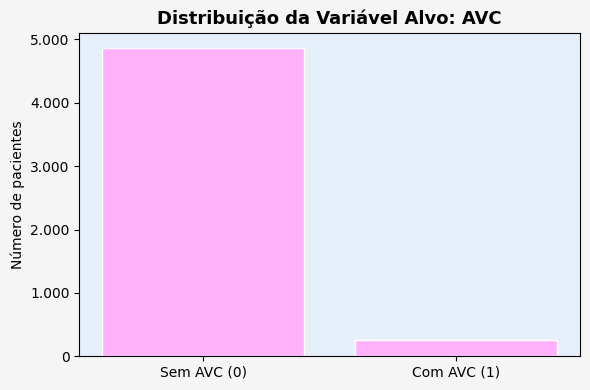

In [15]:
contagem_classes = df_avc["avc"].value_counts().sort_index()
total = contagem_classes.sum()
rotulos = ["Sem AVC (0)", "Com AVC (1)"]

fig, ax = plt.subplots(figsize=(6, 4), facecolor="whitesmoke")
ax.set_facecolor("#e6f0fa")

bars = ax.bar(
    rotulos,
    contagem_classes.values,
    color=["#ffb2f9"],
    edgecolor="white",
)

ax.set_title("Distribuição da Variável Alvo: AVC", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de pacientes")
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

plt.tight_layout()
plt.show()


O gráfico acima confirma visualmente o forte desbalanceamento da variável resposta, conforme já havia sido verificado na análise de tabelas.

#### **2.6.2. Distribuição Percentual de Atributos Binários e Categóricos**

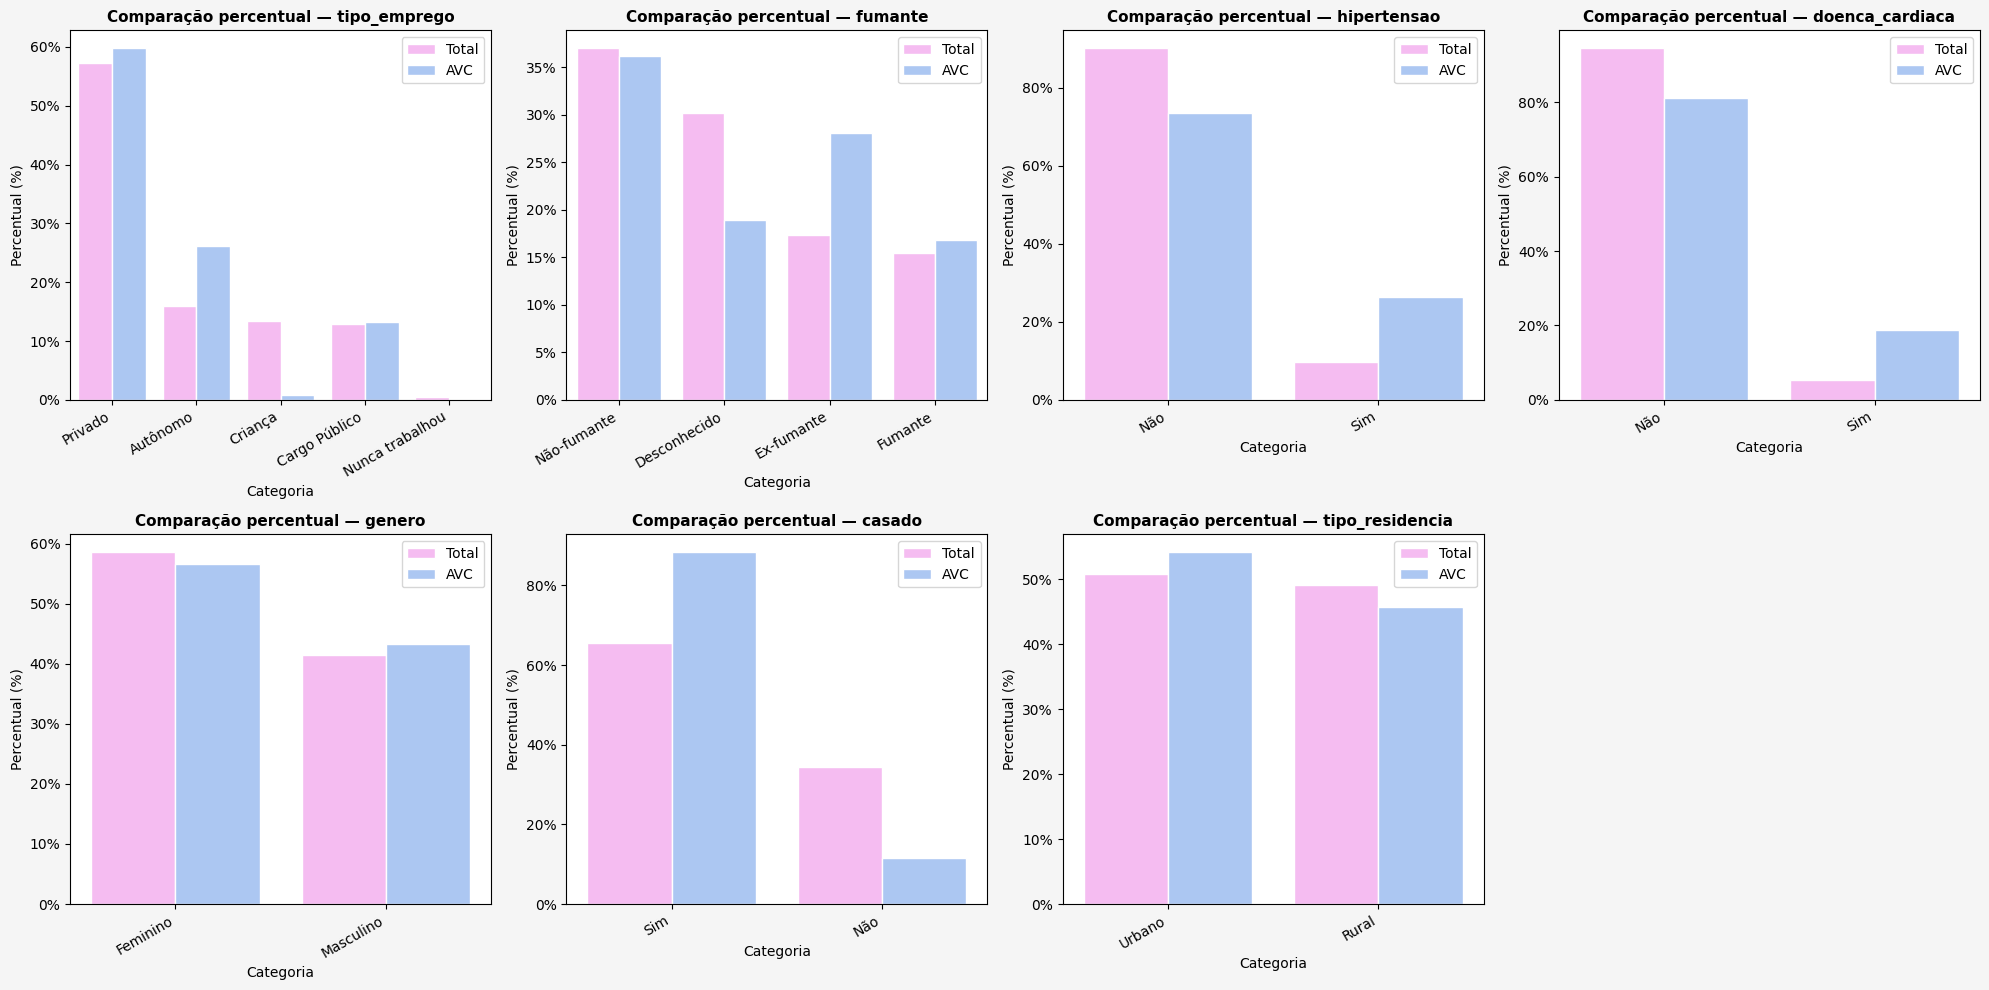

In [16]:
colunas_para_visualizar = [
    c for c in COLUNAS_CATEGORICAS + COLUNAS_BINARIAS if c != "avc"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor="whitesmoke")
axes = axes.flatten()

for i, col in enumerate(colunas_para_visualizar):
    dist_total = df_avc_exibicao[col].value_counts(normalize=True) * 100
    dist_avc = (
        df_avc_exibicao[df_avc_exibicao["avc"] == 1][col].value_counts(normalize=True)
        * 100
    )

    categorias = dist_total.index
    df_plot = pd.DataFrame(
        {
            "Categoria": list(categorias) * 2,
            "Percentual": list(dist_total.values)
            + list(dist_avc.reindex(categorias).fillna(0).values),
            "Grupo": ["Total"] * len(categorias) + ["AVC"] * len(categorias),
        }
    )

    sns.barplot(
        data=df_plot,
        x="Categoria",
        y="Percentual",
        hue="Grupo",
        palette={"Total": "#ffb2f9", "AVC": "#a1c4fd"},
        edgecolor="white",
        ax=axes[i],
    )

    plt.setp(axes[i].get_xticklabels(), rotation=30, ha="right")
    axes[i].set_ylabel("Percentual (%)")
    axes[i].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    axes[i].set_title(f"Comparação percentual — {col}", fontsize=11, fontweight="bold")
    axes[i].legend()

for j in range(len(colunas_para_visualizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Os gráficos comparativos demonstram a distribuição percentual de cada categoria no total do dataset e entre pacientes com AVC:

- **`genero`:** A distribuição por gênero entre casos de AVC é muito próxima da amostra total, sugerindo que o gênero tem poder preditivo limitado.

- **`casado`:** Pacientes casados são proporcionalmente mais representados entre os casos de AVC, provavelmente refletindo a possível correlação entre estado civil e idade, conforme mencionado anteriormente.

- **`tipo_emprego`:** As categorias `Privado` e `Autônomo` têm maior frequência relativa entre os casos de AVC. A categoria `Criança` tem frequência praticamente nula de AVCs, reforçando a influência da idade.

- **`hipertensao` e `doenca_cardiaca`:** Ambos apresentam concentração desproporcionalmente maior entre os casos de AVC, corroborando a **hipótese 2**.

- **`fumante`:** As frequências relativas de `Ex-fumante` e `Fumante` são maiores nos casos de AVC em relação ao total, apoiando a **hipótese 4**.

#### **2.6.3. Taxa de Ocorrência de AVC por Atributo Binários ou Categóricos**

O gráfico a seguir complementa a análise anterior ao mostrar, para cada categoria, qual proporção de seus membros apresentou AVC, alternativa mais direta para identificar categorias de risco.

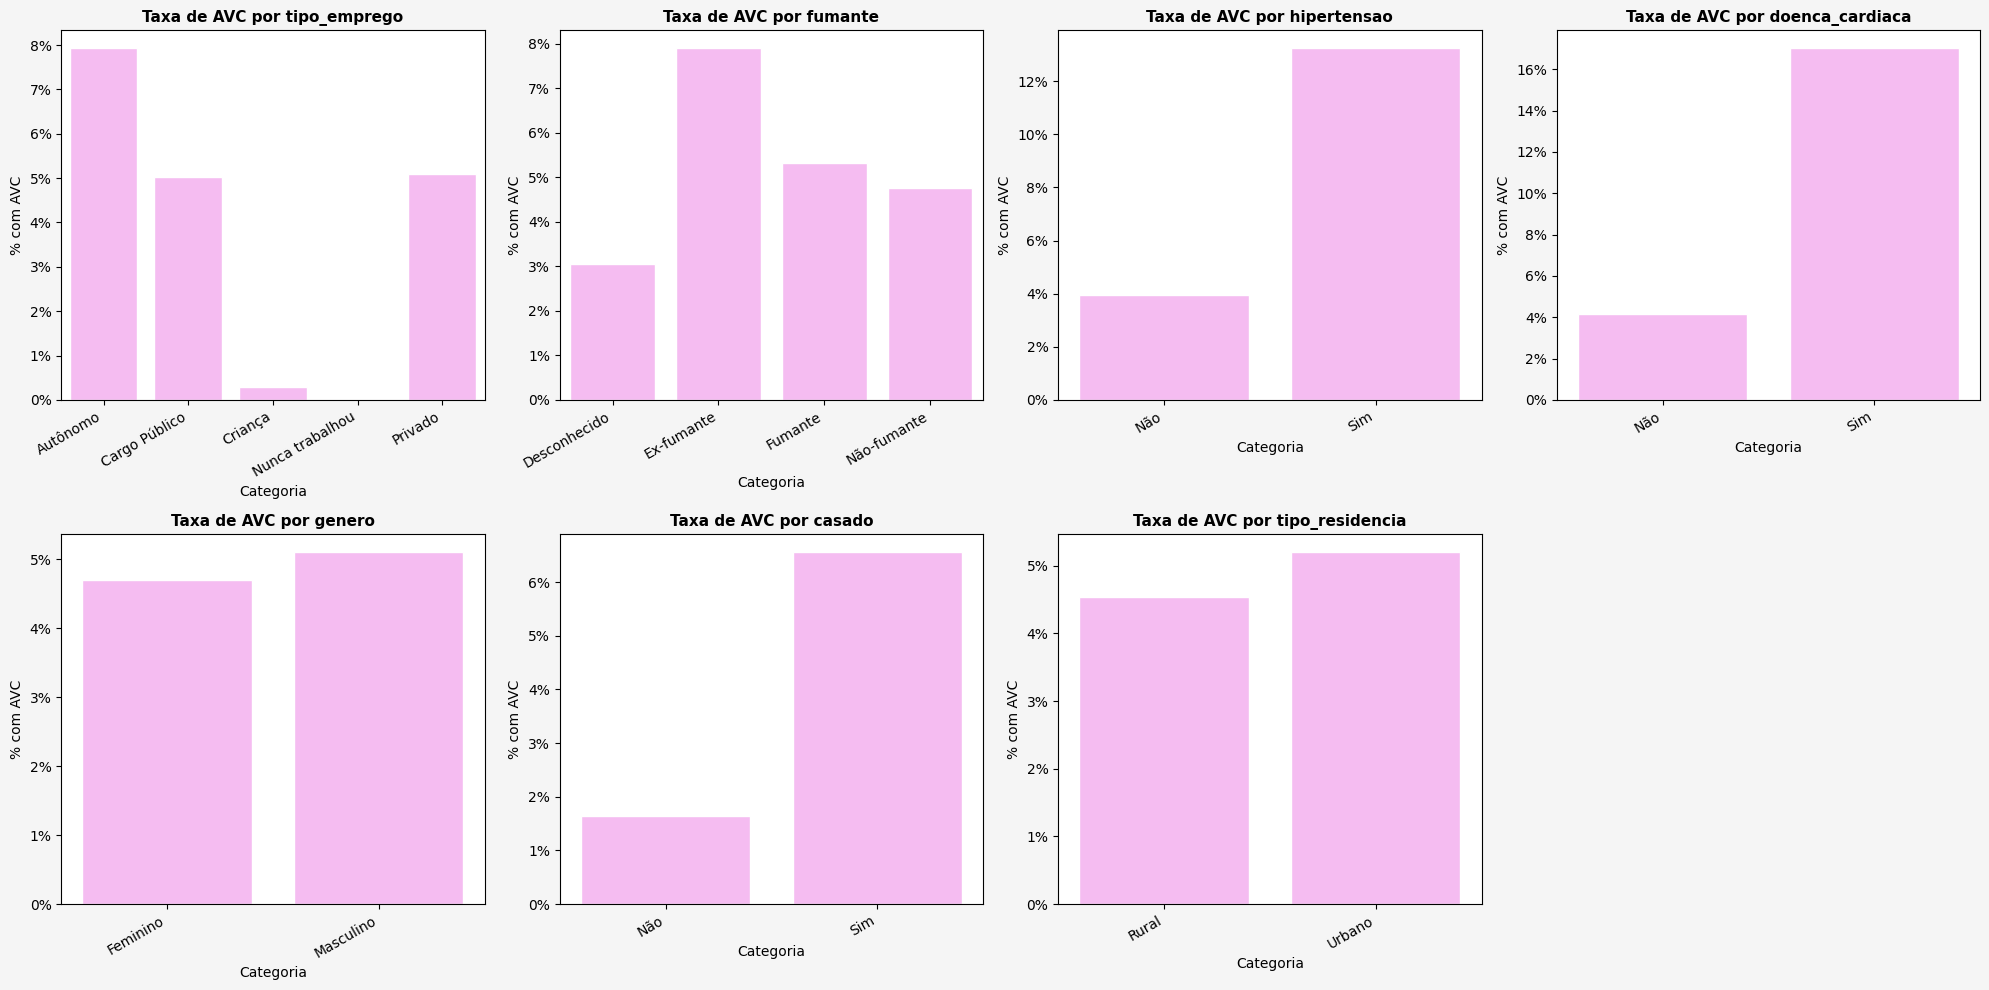

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), facecolor="whitesmoke")
axes = axes.flatten()

for i, col in enumerate(colunas_para_visualizar):
    taxa_avc = df_avc_exibicao.groupby(col)["avc"].mean() * 100

    df_plot = pd.DataFrame({"Categoria": taxa_avc.index, "Taxa_AVC": taxa_avc.values})

    sns.barplot(
        data=df_plot,
        x="Categoria",
        y="Taxa_AVC",
        color="#ffb2f9",
        edgecolor="white",
        ax=axes[i],
    )

    plt.setp(axes[i].get_xticklabels(), rotation=30, ha="right")
    axes[i].set_ylabel("% com AVC")
    axes[i].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    axes[i].set_title(f"Taxa de AVC por {col}", fontsize=11, fontweight="bold")

for j in range(len(colunas_para_visualizar), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

A visualização da taxa de AVC por categoria reforça e detalha os pontos levantados anteriormente:

- Pacientes com hipertensão e doenças cardíacas apresentam taxa de AVC substancialmente mais alta, corroborando a **hipótese 2** e reforçando esses atributos como relevantes preditores para a modelagem;

- `tipo_residencia` e `genero` não apresentam diferenças expressivas entre categorias, indicando menor poder discriminativo;

- Para `fumante`, ex-fumantes e fumantes ativos têm taxa de AVC superior à de não-fumantes, apoiando a **hipótese 4**.

#### **2.6.4. Matriz de Correlação de Atributos Binários e Numéricos Contínuos**

Para avaliar as relações entre variáveis, o coeficiente de Pearson não é adequado para todos os pares do dataset, uma vez que pressupõe que as variáveis sejam contínuas. Por essa razão, utilizamos diferentes métricas conforme a tipagem das colunas:

- **Pearson** para pares contínuo x contínuo. É a medida padrão para variáveis contínuas, mensurando a força da relação linear entre elas. Os valores oscilam entre -1 (correlação forte negativa) e 1 (correlação forte positiva);

- **Point-biserial** para pares contínuo x binário. É a medida apropriada quando uma variável é contínua e a outra é binária, sendo matematicamente equivalente ao Pearson aplicado a esse caso específico. Os valores também oscilam entre -1 e 1, e um baixo p-valor indica a rejeição da hipótese nula de ausência de correlação;

- **Phi (φ)** para pares binário x binário. É a medida adequada para esse tipo de par, derivada do qui-quadrado e normalizada para o intervalo [-1, 1], o que facilita a comparação com os demais coeficientes na matriz.

Por fim, uma vez calculados os coeficientes correspondentes, os valores serão plotados em uma matriz única de correlação, de modo a facilitar a visualização.

=== Correlações Point-Biserial: contínuo x binário ===
╒════════════════╤═════════════════╤══════════════════════╤═══════════╕
│    Contínuo    │     Binário     │  r (point-biserial)  │  p-valor  │
╞════════════════╪═════════════════╪══════════════════════╪═══════════╡
│     idade      │   hipertensao   │        0.2764        │     0     │
├────────────────┼─────────────────┼──────────────────────┼───────────┤
│     idade      │ doenca_cardiaca │        0.2638        │     0     │
├────────────────┼─────────────────┼──────────────────────┼───────────┤
│     idade      │       avc       │        0.2453        │     0     │
├────────────────┼─────────────────┼──────────────────────┼───────────┤
│     idade      │     genero      │       -0.0276        │  0.0483   │
├────────────────┼─────────────────┼──────────────────────┼───────────┤
│     idade      │     casado      │        0.6791        │     0     │
├────────────────┼─────────────────┼──────────────────────┼───────────┤
│     ida

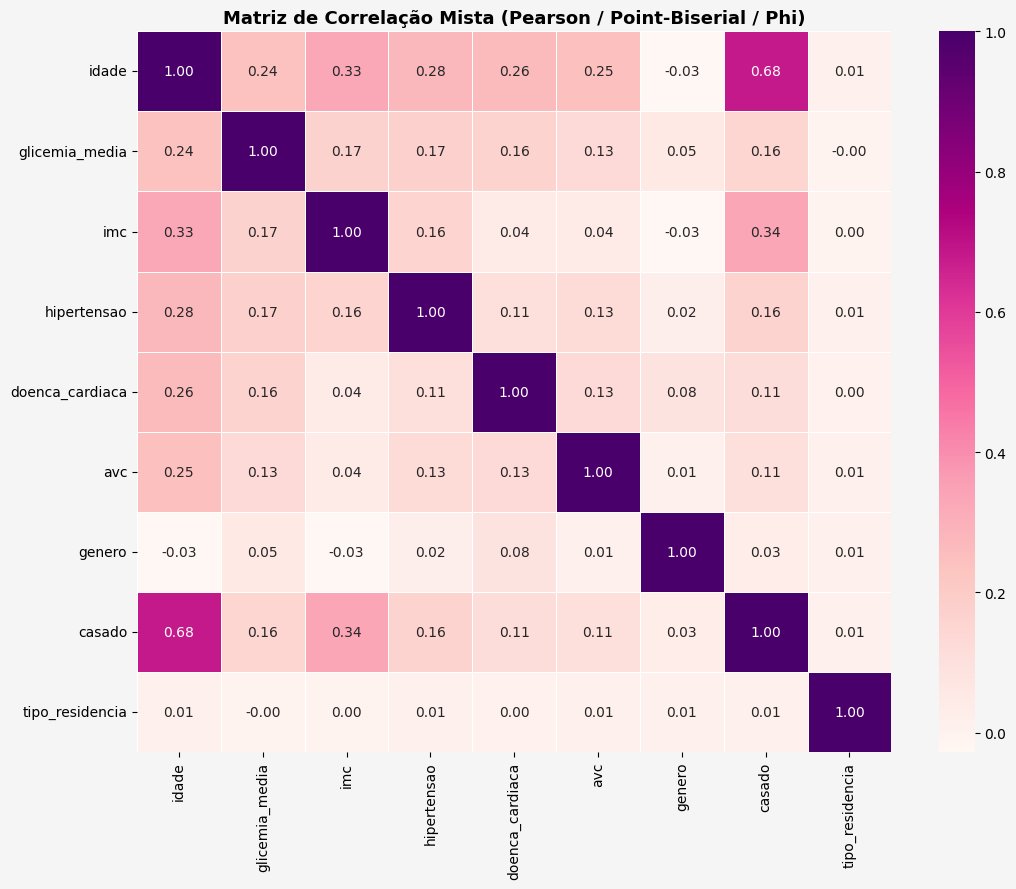

In [18]:
def phi_coef(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    return np.sqrt(chi2 / n)


registros_pb = []
for col_cont in COLUNAS_CONTINUAS:
    for col_bin in COLUNAS_BINARIAS:
        r, p = pointbiserialr(df_avc[col_bin], df_avc[col_cont])
        registros_pb.append(
            {
                "Contínuo": col_cont,
                "Binário": col_bin,
                "r (point-biserial)": round(r, 4),
                "p-valor": round(p, 4),
            }
        )

df_pb = pd.DataFrame(registros_pb)
print("=== Correlações Point-Biserial: contínuo x binário ===")
print(
    tabulate(
        df_pb.values.tolist(),
        headers=df_pb.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_pb.columns),
    )
)

registros_phi = []
for i, col_a in enumerate(COLUNAS_BINARIAS):
    for col_b in COLUNAS_BINARIAS[i + 1 :]:
        phi = phi_coef(df_avc[col_a], df_avc[col_b])
        registros_phi.append(
            {
                "Binário A": col_a,
                "Binário B": col_b,
                "φ (phi)": round(phi, 4),
            }
        )

df_phi = pd.DataFrame(registros_phi)
print("=== Correlações Phi (φ): binário x binário ===")
print(
    tabulate(
        df_phi.values.tolist(),
        headers=df_phi.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_phi.columns),
    )
)

n_cont = len(COLUNAS_CONTINUAS)
n_bin = len(COLUNAS_BINARIAS)
n_total = n_cont + n_bin
matriz_mista = pd.DataFrame(
    np.nan,
    index=COLUNAS_CONTINUAS + COLUNAS_BINARIAS,
    columns=COLUNAS_CONTINUAS + COLUNAS_BINARIAS,
)

matriz_pearson_cc = df_avc[COLUNAS_CONTINUAS].corr(method="pearson")
for c1 in COLUNAS_CONTINUAS:
    for c2 in COLUNAS_CONTINUAS:
        matriz_mista.loc[c1, c2] = matriz_pearson_cc.loc[c1, c2]

for col_cont in COLUNAS_CONTINUAS:
    for col_bin in COLUNAS_BINARIAS:
        r, _ = pointbiserialr(df_avc[col_bin], df_avc[col_cont])
        matriz_mista.loc[col_cont, col_bin] = r
        matriz_mista.loc[col_bin, col_cont] = r

for i, col_a in enumerate(COLUNAS_BINARIAS):
    for col_b in COLUNAS_BINARIAS[i:]:
        phi = phi_coef(df_avc[col_a], df_avc[col_b]) if col_a != col_b else 1.0
        matriz_mista.loc[col_a, col_b] = phi
        matriz_mista.loc[col_b, col_a] = phi

matriz_mista = matriz_mista.astype(float)

fig, ax = plt.subplots(figsize=(11, 9), facecolor="whitesmoke")
sns.heatmap(
    matriz_mista,
    annot=True,
    fmt=".2f",
    cmap="RdPu",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_title(
    "Matriz de Correlação Mista (Pearson / Point-Biserial / Phi)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Em relação à análise de correlação, destacam-se os seguintes pontos:

- **`avc` × `idade` (r = 0,25, p < 0,05):** O baixo p-valor indica a rejeição da hipótese nula de correlação zero, e o coeficiente point-biserial confirma uma relação positiva moderada entre as variáveis, reforçando a **hipótese 1**;

- **`avc` × `glicemia_media` (r = 0,13, p < 0,05):** O coeficiente point-biserial indica uma relação positiva fraca, porém estatisticamente significativa, sugerindo que níveis mais elevados de glicemia média estão associados a maior ocorrência de AVC, conforme postulado na **hipótese 3**;

- **`avc` × `imc` (r = 0,05, p < 0,05):** Embora estatisticamente significativa, o coeficiente point-biserial indica uma correlação praticamente nula, o que enfraquece a **hipótese 5**;

- **`avc` × `hipertensao` (φ = 0,13) e `avc` × `doenca_cardiaca` (φ = 0,13):** Os coeficientes phi indicam correlações positivas fracas, mas consistentes com a **hipótese 2**: pacientes com essas comorbidades apresentam maior associação com AVC. A magnitude reduzida é esperada dado o forte desbalanceamento das variáveis binárias;

- **`casado` × `idade` (r = 0,69):** A correlação point-biserial mais elevada da matriz (`casado`) é, em grande parte, proxy de `idade`, o que deve ser considerado ao interpretar ambas as variáveis como preditores independentes;

- **`avc` × `casado` (φ = 0,11):** Correlação phi positiva e fraca, provavelmente intermediada pela variável `idade`, conforme mencionado anteriormente;

- **`avc` × `genero` (φ = 0,00) e `avc` × `tipo_residencia` (φ = 0,01):** Correlações phi próximas de zero, sugerindo ausência de associação linear com a variável-resposta, em linha com o que já havia sido verificado para os gráficos de incidência de AVC por atributo;

- **Demais atributos:** Ausência de correlações elevadas entre os preditores, sugerindo baixa multicolinearidade no conjunto de dados.

#### **2.6.5. Gráficos de Densidade de Variáveis Numéricas Contínuas**

Os gráficos a seguir analisam a distribuição dos atributos numéricos contínuos separando os pacientes entre os que apresentaram AVC (classe 1) e os que não apresentaram (classe 0).

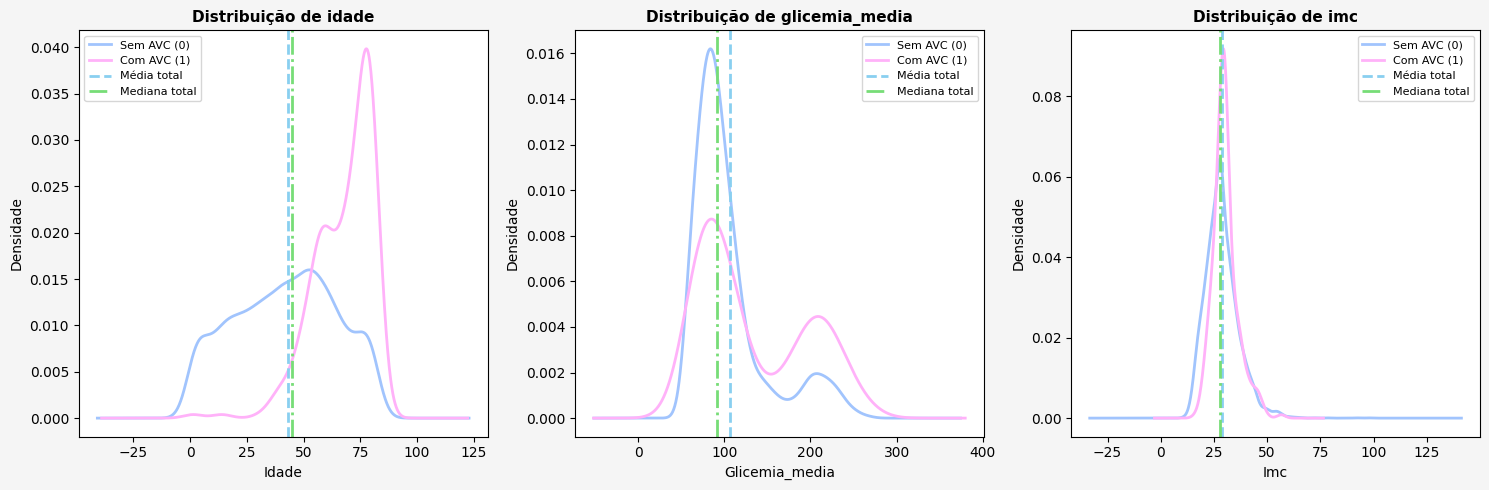

In [19]:
fig, axes = plt.subplots(
    1, len(COLUNAS_CONTINUAS), figsize=(15, 5), facecolor="whitesmoke"
)

for ax, coluna in zip(axes, COLUNAS_CONTINUAS):
    for classe, grupo in df_avc.groupby("avc"):
        label = "Com AVC (1)" if classe == 1 else "Sem AVC (0)"
        cor = "#ffb2f9" if classe == 1 else "#a1c4fd"
        grupo[coluna].plot.kde(ax=ax, label=label, color=cor, linewidth=2)

    ax.axvline(
        df_avc[coluna].mean(),
        color="#89CFF0",
        linestyle="--",
        linewidth=2,
        label="Média total",
    )
    ax.axvline(
        df_avc[coluna].median(),
        color="#77dd77",
        linestyle="-.",
        linewidth=2,
        label="Mediana total",
    )

    ax.set_title(f"Distribuição de {coluna}", fontsize=11, fontweight="bold")
    ax.set_xlabel(coluna.capitalize())
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Os gráficos de densidade (KDE) revelam padrões importantes:

- **`idade`:** A distribuição dos pacientes com AVC é claramente deslocada para idades mais avançadas, com pico entre 60 e 80 anos. Isso reforça a **hipótese 1**;

- **`glicemia_media`:** A distribuição dos pacientes com AVC apresenta cauda mais longa à direita, indicando maior concentração de casos com glicemia elevada: consistente com a **hipótese 3**;

- **`imc`:** As distribuições entre as duas classes são mais próximas, sugerindo menor poder discriminativo isolado, conforme já verificado parcialmente na matriz de correlação. Há uma leve tendência de IMC mais elevado entre os casos com AVC, coerente com a **hipótese 5**, embora o efeito seja fraco.

#### **2.6.6. Box-Plot de Variáveis Numéricas Contínuas**

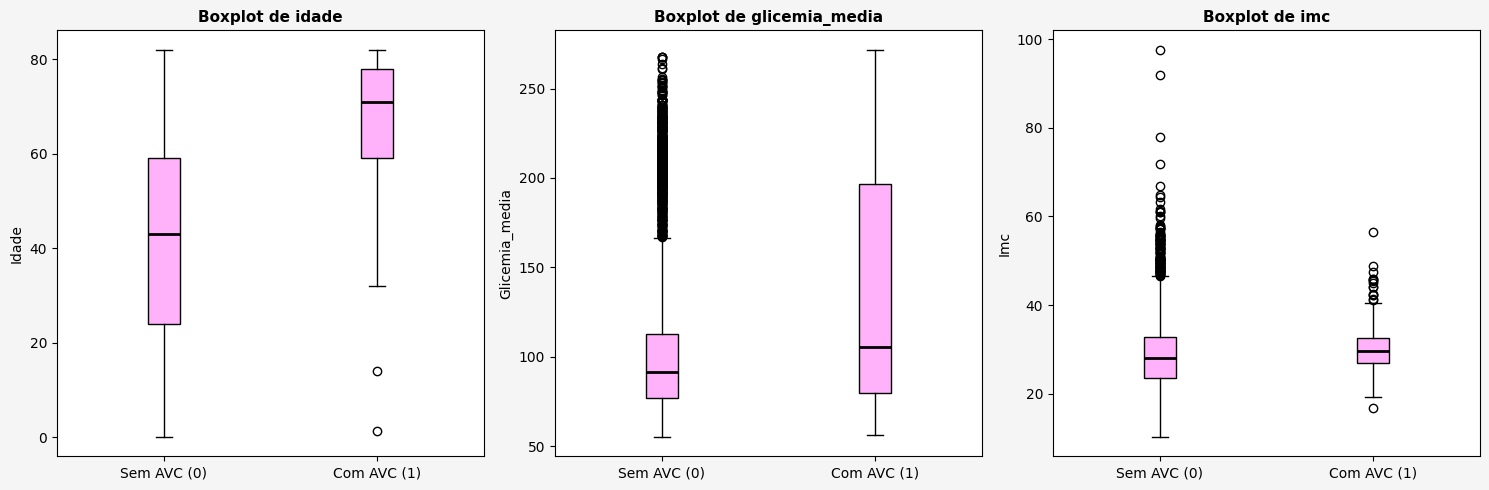

In [20]:
fig, axes = plt.subplots(1, len(COLUNAS_CONTINUAS), figsize=(5 * len(COLUNAS_CONTINUAS), 5), facecolor="whitesmoke")

for ax, coluna in zip(axes, COLUNAS_CONTINUAS):
    dados_por_classe = [
        df_avc[df_avc["avc"] == 0][coluna].dropna(),
        df_avc[df_avc["avc"] == 1][coluna].dropna(),
    ]

    ax.boxplot(
        dados_por_classe,
        tick_labels=["Sem AVC (0)", "Com AVC (1)"],
        patch_artist=True,
        boxprops=dict(facecolor="#ffb2f9", color="black"),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
    )

    ax.set_title(f"Boxplot de {coluna}", fontsize=11, fontweight="bold")
    ax.set_ylabel(coluna.capitalize())

plt.tight_layout()
plt.show()

Os box-plots confirmam as conclusões dos KDE e acrescentam informações sobre dispersão:

- **`idade`:** A mediana dos pacientes com AVC é visivelmente superior à dos sem AVC, sem sobreposição significativa entre as caixas, reforçando a **hipótese 1**;

- **`glicemia_media`:** Mediana ligeiramente superior para instâncias que apresentam AVC, com maior dispersão e diversos outliers em ambas as classes. Resultado consistente com a **hipótese 3**;

- **`imc`:** Distribuições muito semelhantes entre as classes, com medianas próximas e outliers em ambos os grupos. Esse ponto reforça o que já verificamos na matriz de correlação e na análise dos gráficos de densidade: o atributo parece não ter poder preditivo forte o suficiente para a modelagem dos casos de AVC, o que enfraquece a **hipótese 5**.

Após a análise dos box-plots, optou-se por manter os valores identificados como outliers na base, pelas seguintes razões:

- Em dados clínicos, os registros fora dos whiskers do box-plot não são necessariamente erros. Pacientes com risco de AVC frequentemente apresentarão perfis atípicos, como hiperglicemia severa ou IMC muito elevado. Esse ponto torna a presença de valores extremos esperada e informativa em termos de modelagem;

- Tendo em vista que os dados são fortemente desbalanceados, e que já verificamos que existem correlações positivas entre os atributos `imc` e `glicemia_media` com a variável resposta `avc`, retirar valores extremos poderia afetar desproporcionalmente a classe com AVC;

- Os box-plots avaliam cada variável isoladamente. Um paciente com IMC e glicemia elevados, por exemplo, poderia aparecer como outlier em ambas as análises, mas o perfil combinado é clinicamente válido e relevante como um potencial fator de risco, não como uma anomalia a ser descartada.

### **2.7. Análise Gráfica da Categorização de Atributos Numéricos Contínuos**

A discretização de atributos numéricos contínuos consiste em transformar valores quantitativos em categorias, agrupando observações em faixas com significado clínico. Essa transformação pode ser interessante por algumas razões:

- **Interpretabilidade:** faixas como "Idoso" ou "Diabetes" são mais intuitivas do que valores brutos como "68 anos" ou "glicemia média de 130 mg/dL", facilitando a comunicação dos resultados;

- **Captura de não-linearidades:** com base na análise gráfica definida em 2.6.5, verificamos que a relação entre idade e AVC não parece ser linear: o risco cresce de forma mais acentuada a partir de determinadas idades. A discretização pode ajudar na captura dessas rupturas;

- **Redução de ruído:** ao agrupar valores próximos em uma mesma categoria, pequenas variações numéricas sem relevância clínica deixam de influenciar o modelo.

Em que pesem os argumentos apresentados acima, inicialmente **não alteraremos o conjunto original de dados**, criando um dataframe temporário apenas para a visualização e o entendimento das informações antes da efetivação do tratamento.

Com isso, assumiram-se as seguintes classes, com base na interpretação dos atributos:

| Faixa de Idade | Classe |
|:---:|:---:|
| De 0 a 15 anos (exclusive) | Criança/Adolescente |
| De 15 anos a 35 anos (exclusive) | Jovem Adulto |
| De 35 a 60 anos (exclusive) | Adulto |
| 60 anos ou mais | Idoso |

Aplicaremos, ainda, uma discretização das informações de glicemia. Para a separação em categorias, utilizou‑se como referência a [Portaria do Ministério da Saúde — PCDT Diabetes Tipo 2 (PCDTDM2)](https://www.gov.br/conitec/pt-br/midias/protocolos/PCDTDM2.pdf), quadro 4, página 7, que indica os valores de referência conforme a tabela a seguir:

| Faixa de Glicemia | Classe |
|:---:|:---:|
| De 0 a 100 (exclusive) | Normal |
| De 100 a 126 (exclusive) | Pré-diabetes |
| 126 ou mais | Diabetes |

Por fim, aplicaremos a discretização também nas informações de IMC. Para a separação em categorias, utilizou-se como referência a [Portaria do Ministério da Saúde - Sobrepeso e Obesidade em Adultos](https://www.gov.br/conitec/pt-br/midias/protocolos/resumidos/PCDTResumidodeSobrepesoObesidade.pdf.pdf). Cabe pontuar que, embora o referencial indique a classificação leve em consideração a classificação para indivíduos adultos, a análise exploratória anterior indicou que crianças e adolescentes não são muito fortemente expostos ao risco de AVC, de modo que optamos por seguir com essa classificação:

| Faixa de IMC | Classe |
|:---:|:---:|
| De 0 a 18,5 (exclusive) | Abaixo do Peso |
| De 18,5 a 25 (exclusive) | Normal |
| De 25 a 30 (exclusive) | Sobrepeso |
| De 30 a 35 (exclusive) | Obesidade Grau I |
| De 35 a 40 (exclusive) | Obesidade Grau II |
| 40 ou mais | Obesidade Grau III |

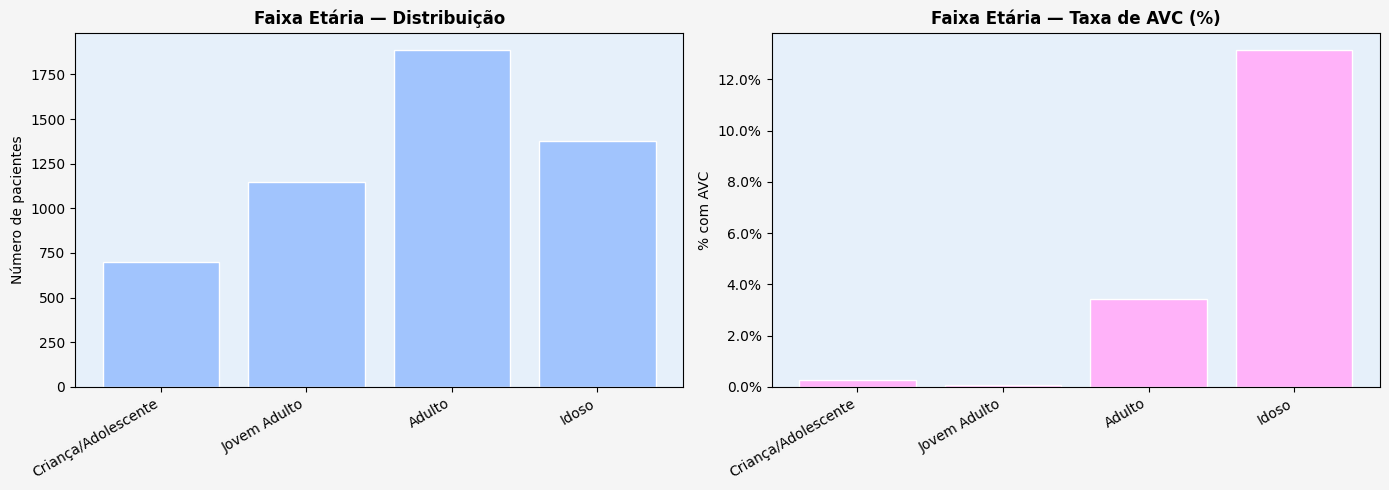

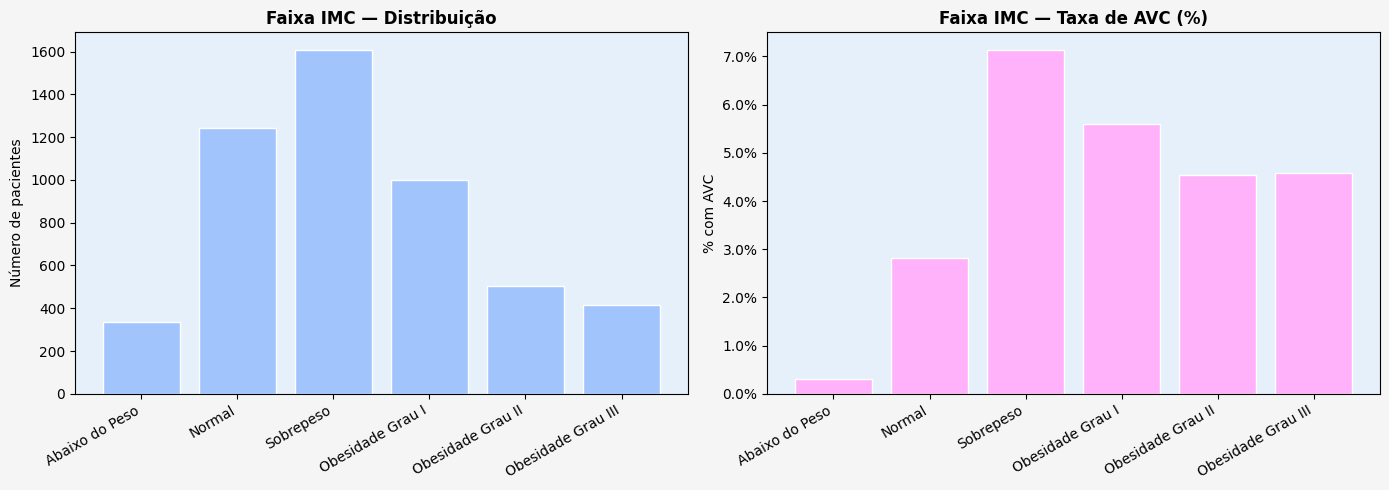

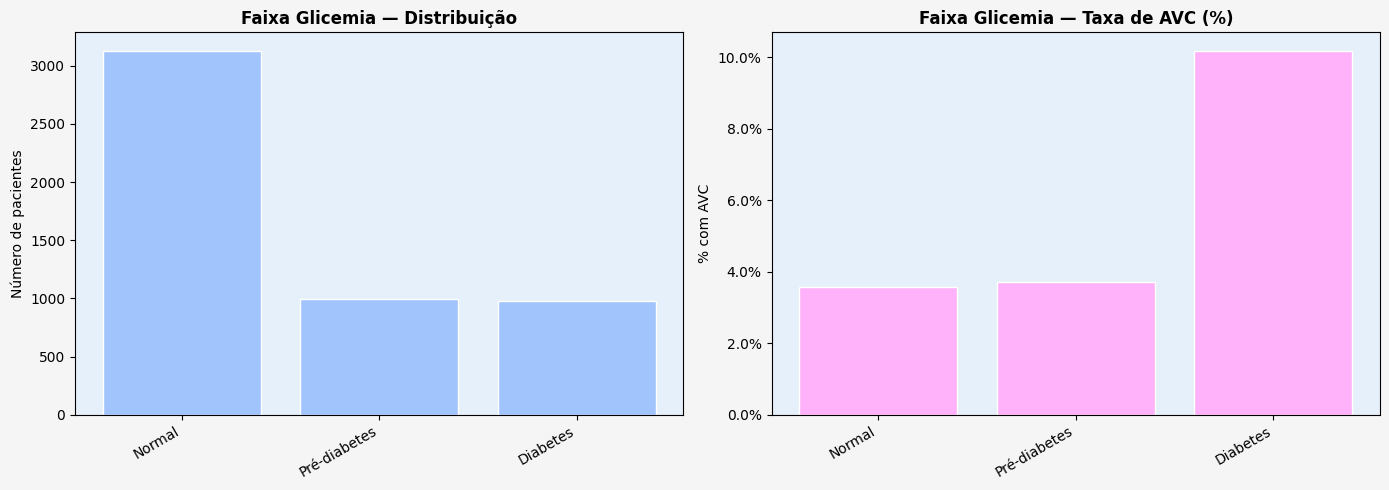

In [21]:
CONFIG_DISCRETIZACAO = {
    "idade": {
        "coluna_nova": "idade_discretizada",
        "bins": [0, 15, 35, 60, float("inf")],
        "labels": ["Criança/Adolescente", "Jovem Adulto", "Adulto", "Idoso"],
    },
    "imc": {
        "coluna_nova": "imc_discretizado",
        "bins": [0, 18.5, 25, 30, 35, 40, float("inf")],
        "labels": [
            "Abaixo do Peso",
            "Normal",
            "Sobrepeso",
            "Obesidade Grau I",
            "Obesidade Grau II",
            "Obesidade Grau III",
        ],
    },
    "glicemia_media": {
        "coluna_nova": "glicemia_discretizado",
        "bins": [0, 100, 126, float("inf")],
        "labels": ["Normal", "Pré-diabetes", "Diabetes"],
    },
}


def aplicar_discretizacao(df_origem, config):
    for coluna_original, params in config.items():
        coluna_nova = params["coluna_nova"]
        labels = params["labels"]
        df_origem[coluna_nova] = pd.Categorical(
            pd.cut(
                df_origem[coluna_original],
                bins=params["bins"],
                labels=labels,
                right=False,
                include_lowest=True,
            ),
            categories=labels,
            ordered=True,
        )
    df_origem = df_origem.drop(columns=list(config.keys()))
    return df_origem


def plotar_distribuicao_e_taxa(df, coluna, labels, titulo):
    posicoes = list(range(len(labels)))
    contagens = df[coluna].value_counts().reindex(labels).fillna(0).astype(int)
    taxas_avc = (
        df.groupby(coluna, observed=True)["avc"].mean().reindex(labels).fillna(0) * 100
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="whitesmoke")

    axes[0].bar(posicoes, contagens.values, color="#a1c4fd", edgecolor="white")
    axes[0].set_title(f"{titulo} — Distribuição", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Número de pacientes")
    axes[0].set_xticks(posicoes)
    axes[0].set_xticklabels(labels, rotation=30, ha="right")
    axes[0].set_facecolor("#e6f0fa")

    axes[1].bar(posicoes, taxas_avc.values, color="#ffb2f9", edgecolor="white")
    axes[1].set_title(f"{titulo} — Taxa de AVC (%)", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("% com AVC")
    axes[1].set_xticks(posicoes)
    axes[1].set_xticklabels(labels, rotation=30, ha="right")
    axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))
    axes[1].set_facecolor("#e6f0fa")

    plt.tight_layout()
    plt.show()


df_subgrupo = df_avc[
    [
        "idade",
        "hipertensao",
        "doenca_cardiaca",
        "glicemia_media",
        "imc",
        "avc",
        "fumante",
    ]
].copy()

df_subgrupo = aplicar_discretizacao(df_subgrupo, CONFIG_DISCRETIZACAO)

TITULOS_DISCRETIZACAO = {
    "idade": "Faixa Etária",
    "imc": "Faixa IMC",
    "glicemia_media": "Faixa Glicemia",
}

for coluna_original, config in CONFIG_DISCRETIZACAO.items():
    plotar_distribuicao_e_taxa(
        df=df_subgrupo,
        coluna=config["coluna_nova"],
        labels=config["labels"],
        titulo=TITULOS_DISCRETIZACAO[coluna_original],
    )

Com base nos gráficos acima, incluem-se os seguintes comentários:

- **Faixa Etária:** A categorização explicita o que os gráficos de densidade já sugeriam de maneira contínua: o risco de AVC cresce de forma acentuada com a idade. Enquanto crianças/adolescentes e jovens adultos apresentam risco praticamente nulo de desenvolvimento de AVC, a proporção cresce significativamente para adultos e idosos;

- **Faixa IMC:** Corrobora-se o verificado na análise contínua: existe uma leve tendência de maior incidência de AVCs para maiores valores de IMC, mas não se trata de progressão contínua.  A alta proporção de "sobrepeso" pode estar correlacionada ao comportamento de outra variável, o que verificaremos a seguir.

- **Faixa Glicemia:** Para esse atributo, há uma pontuação interessante: embora o comportamento no gráfico de densidade indique o aumento do risco conforme mais altos são os valores de glicemia, aparentemente não há alteração significativa entre a população categorizada como "Normal" e a categorizada como "Pré-diabetes". Isso sugere que, para que haja real influência na ocorrência de um AVC, o indivíduo deverá apresentar um quadro diabético.

### **2.8. Análise Bivariada Combinada**

Além da análise individual de cada atributo, é de nosso interesse investigar, também, interações entre pares de preditores em relação à ocorrência de AVC. Essa perspectiva é relevante porque o risco clínico de AVC, segundo o consenso médico, raramente é determinado por um único fator: a combinação de múltiplas condições/comorbidades tende a ser mais informativa.

Serão exploradas cinco combinações de interesse clínico:

- **Idade x Hipertensão:** testa se o efeito da hipertensão sobre o risco de AVC é ampliado em pacientes mais velhos (combina a **hipótese 1** com a **hipótese 2**);

- **Idade x Doença Cardíaca:** testa se o efeito da doença cardíaca sobre o risco de AVC é ampliado em pacientes mais velhos (também combina as **hipóteses 1 e 2**);

- **Idade x Glicemia:** testa se a combinação de envelhecimento e glicemia elevada apresenta padrão distinto de risco (combina as **hipóteses 1 e 3**);

- **Idade x IMC:** testa se o efeito do IMC é ampliado em pacientes mais velhos (combina as **hipóteses 1 e 5**);

- **Idade x Fumante:** testa se o efeito do atributo de tabagismo é alterado conforme a idade (combina **hipóteses 1 e 4**).

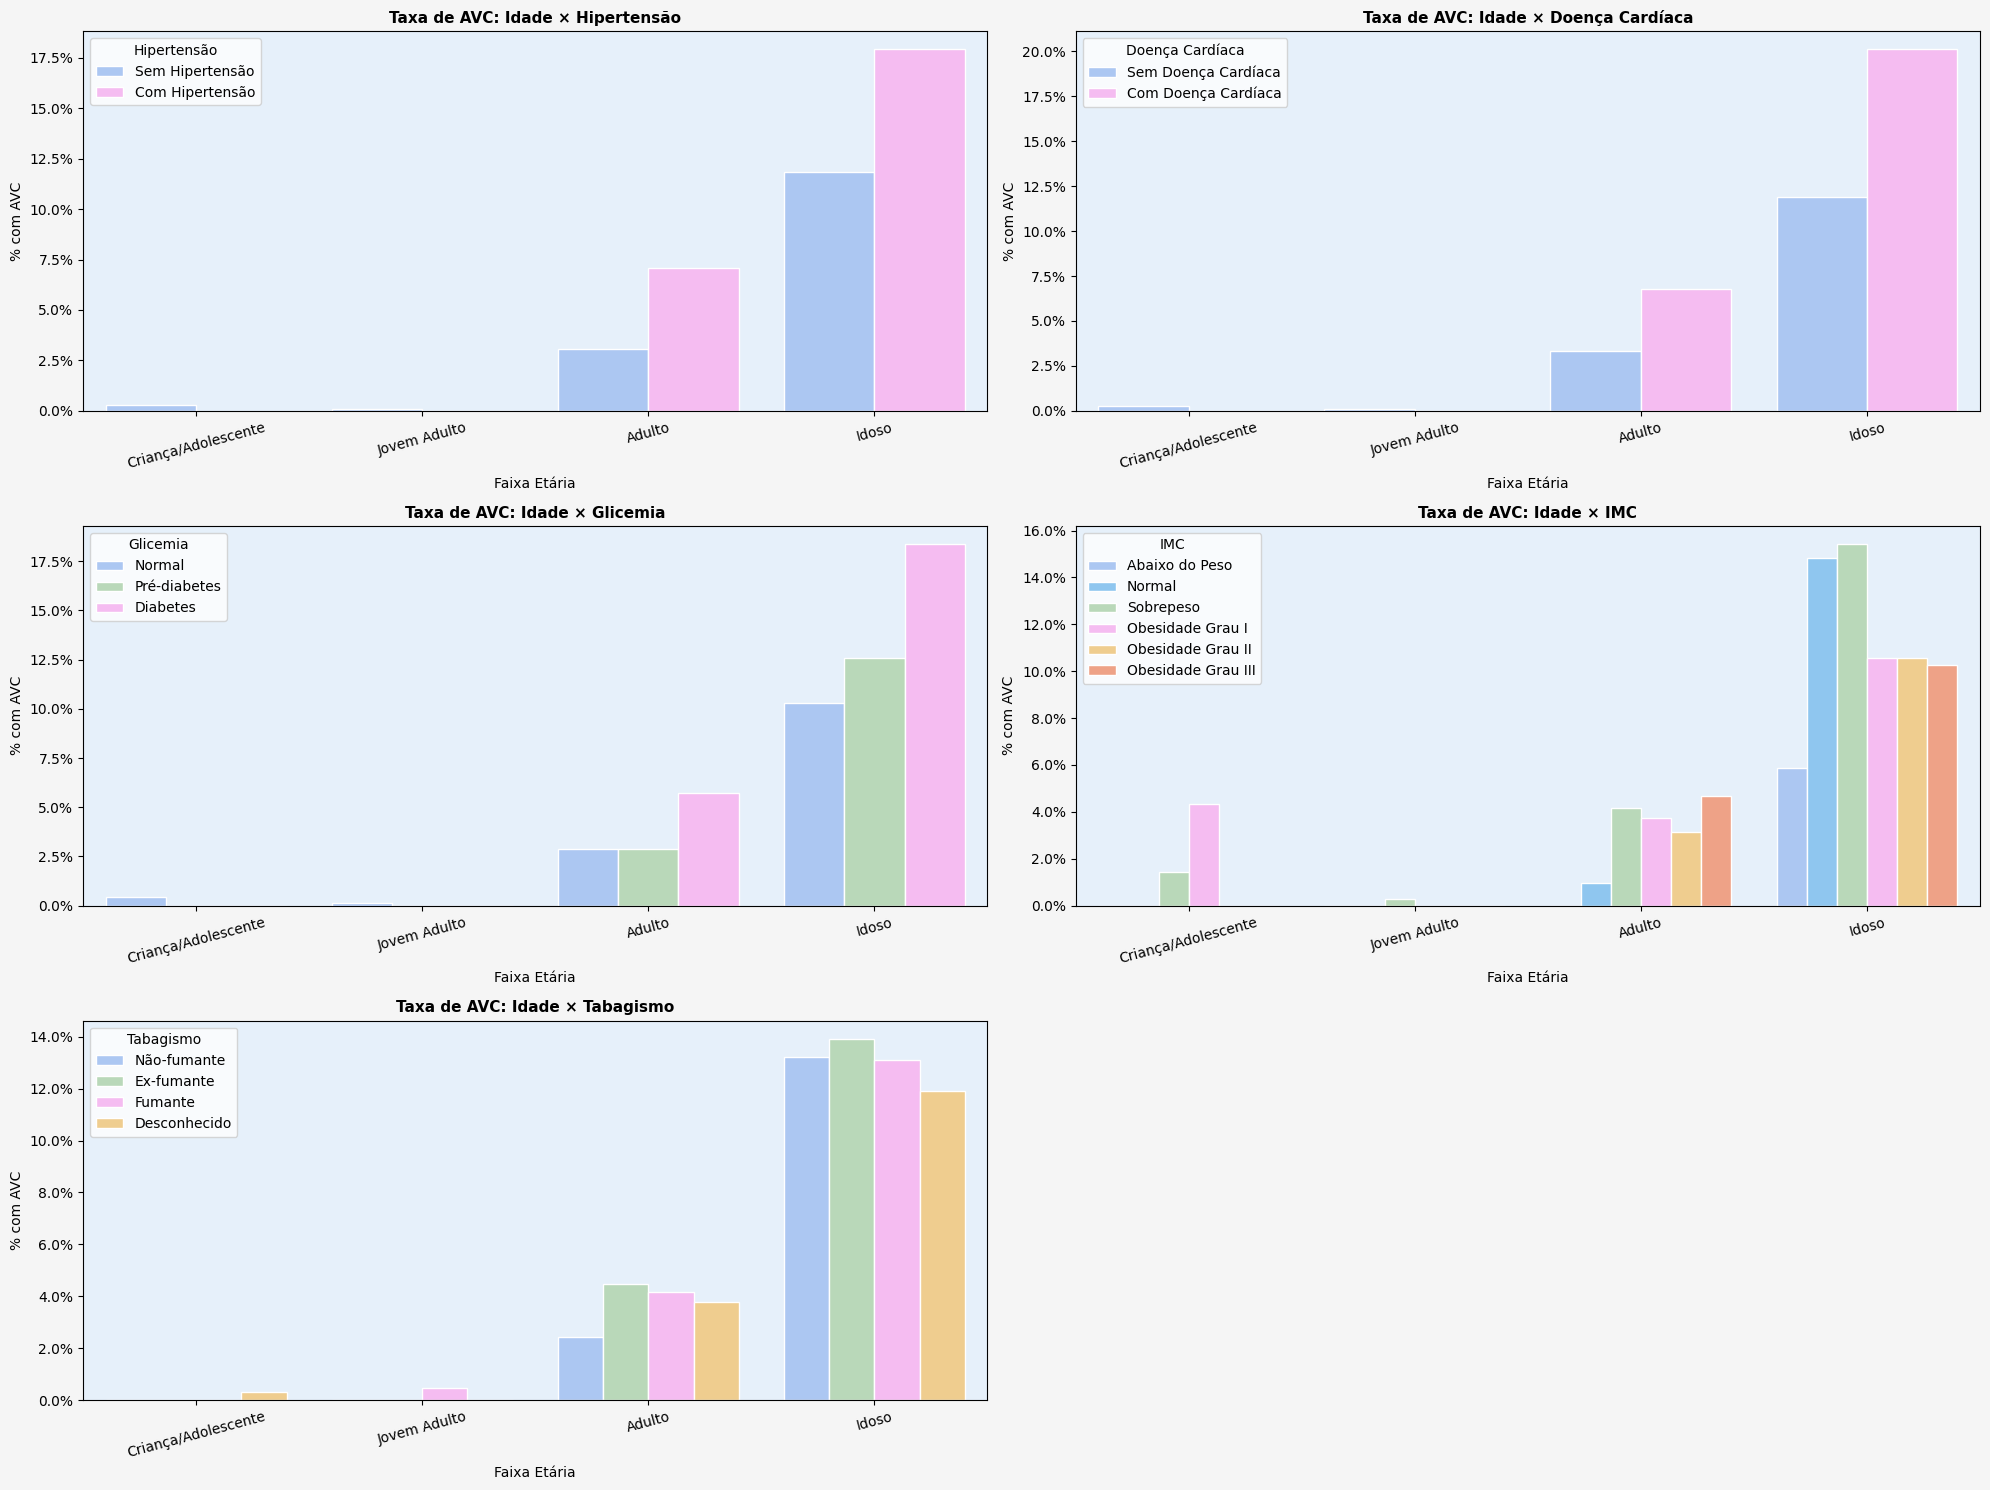

In [22]:
df_subgrupo["hipertensao_label"] = df_subgrupo["hipertensao"].map(
    {0: "Sem Hipertensão", 1: "Com Hipertensão"}
)
df_subgrupo["doenca_cardiaca_label"] = df_subgrupo["doenca_cardiaca"].map(
    {0: "Sem Doença Cardíaca", 1: "Com Doença Cardíaca"}
)

CONFIG_SUBGRUPOS = [
    {
        "coluna_hue": "hipertensao_label",
        "hue_label": "Hipertensão",
        "titulo": "Taxa de AVC: Idade × Hipertensão",
        "palette": {"Sem Hipertensão": "#a1c4fd", "Com Hipertensão": "#ffb2f9"},
        "hue_order": None,
    },
    {
        "coluna_hue": "doenca_cardiaca_label",
        "hue_label": "Doença Cardíaca",
        "titulo": "Taxa de AVC: Idade × Doença Cardíaca",
        "palette": {"Sem Doença Cardíaca": "#a1c4fd", "Com Doença Cardíaca": "#ffb2f9"},
        "hue_order": ["Sem Doença Cardíaca", "Com Doença Cardíaca"],
    },
    {
        "coluna_hue": "glicemia_discretizado",
        "hue_label": "Glicemia",
        "titulo": "Taxa de AVC: Idade × Glicemia",
        "palette": {
            "Normal": "#a1c4fd",
            "Pré-diabetes": "#b4ddb4",
            "Diabetes": "#ffb2f9",
        },
        "hue_order": None,
    },
    {
        "coluna_hue": "imc_discretizado",
        "hue_label": "IMC",
        "titulo": "Taxa de AVC: Idade × IMC",
        "palette": {
            "Abaixo do Peso": "#a1c4fd",
            "Normal": "#7fc8ff",
            "Sobrepeso": "#b4ddb4",
            "Obesidade Grau I": "#ffb2f9",
            "Obesidade Grau II": "#ffd27f",
            "Obesidade Grau III": "#ff9a76",
        },
        "hue_order": [
            "Abaixo do Peso",
            "Normal",
            "Sobrepeso",
            "Obesidade Grau I",
            "Obesidade Grau II",
            "Obesidade Grau III",
        ],
    },
    {
        "coluna_hue": "fumante",
        "hue_label": "Tabagismo",
        "titulo": "Taxa de AVC: Idade × Tabagismo",
        "palette": {
            "Não-fumante": "#a1c4fd",
            "Ex-fumante": "#b4ddb4",
            "Fumante": "#ffb2f9",
            "Desconhecido": "#ffd27f",
        },
        "hue_order": ["Não-fumante", "Ex-fumante", "Fumante", "Desconhecido"],
    },
]

n_graficos = len(CONFIG_SUBGRUPOS)
n_cols = 2
n_rows = math.ceil(n_graficos / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(20, n_rows * 5), facecolor="whitesmoke"
)

for ax, config in zip(axes.flatten(), CONFIG_SUBGRUPOS):
    taxa = (
        df_subgrupo.groupby(
            ["idade_discretizada", config["coluna_hue"]], observed=True
        )["avc"].mean()
        * 100
    ).reset_index()
    taxa.columns = ["Faixa Etária", config["hue_label"], "Taxa AVC (%)"]

    sns.barplot(
        data=taxa,
        x="Faixa Etária",
        y="Taxa AVC (%)",
        hue=config["hue_label"],
        hue_order=config["hue_order"],
        palette=config["palette"],
        edgecolor="white",
        ax=ax,
    )
    ax.set_title(config["titulo"], fontsize=11, fontweight="bold")
    ax.set_ylabel("% com AVC")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))
    ax.set_facecolor("#e6f0fa")
    ax.tick_params(axis="x", labelrotation=15)

for ax in axes.flatten()[n_graficos:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Os gráficos de subgrupos revelam padrões que a análise univariada não consegue capturar:

- **Idade × Hipertensão** e **Idade x Doença Cardíaca**: O efeito dessas variáveis sobre a taxa de AVC parece ser ampliado com o envelhecimento. Pacientes idosos hipertensos ou com doença cardíaca apresentam taxa de AVC consideravelmente superior à de idosos sem essas comorbidades, enquanto nas faixas mais jovens a diferença é menor. Isso sugere interação entre os atributos;

- **Idade x Glicemia**: O padrão é semelhante: a faixa diabética em pacientes idosos parece concentrar mais riscos. Em pacientes mais jovens, ainda que a glicemia esteja elevada, o risco parece ser significativamente menor, reforçando que a idade é o fator mais determinante no dataset (**hipótese 1**);

- **Idade x Tabagismo**: Embora haja maior prevalência de AVC para fumantes e ex-fumantes, as distribuições de cada categoria são muito próximas dentro de cada classe de idade. Isso indica que a idade provavelmente é um preditor muito mais forte, o que enfraquece parcialmente a **hipótese 4**. Cabe pontuar que a categoria "Desconhecido" ainda está presente nessa análise e será tratada na etapa de pré-processamento;

- **Idade x IMC**: Para as faixas mais jovens, notamos que as incidências são praticamente exclusivas a grupos mais agravados de IMC, o que reforça o papel dessa variável como um fator de risco pra além da idade. Na análise univariada, verificamos que os dados de incidência estão mais concentrados no grupo de "Sobrepeso", mas a análise bivariada demonstra que há uma forte concentração desses casos no grupo de Idosos. Quanto a isso, cabe pontuar que a condição de obesidade tende a reduzir a expectativa de vida, o que implica que indivíduos com obesidade grave frequentemente apresentam complicações de saúde em idades mais precoces, o que pode limitar a probabilidade de alcançarem faixas etárias mais avançadas. Podemos verificar esse ponto a seguir.

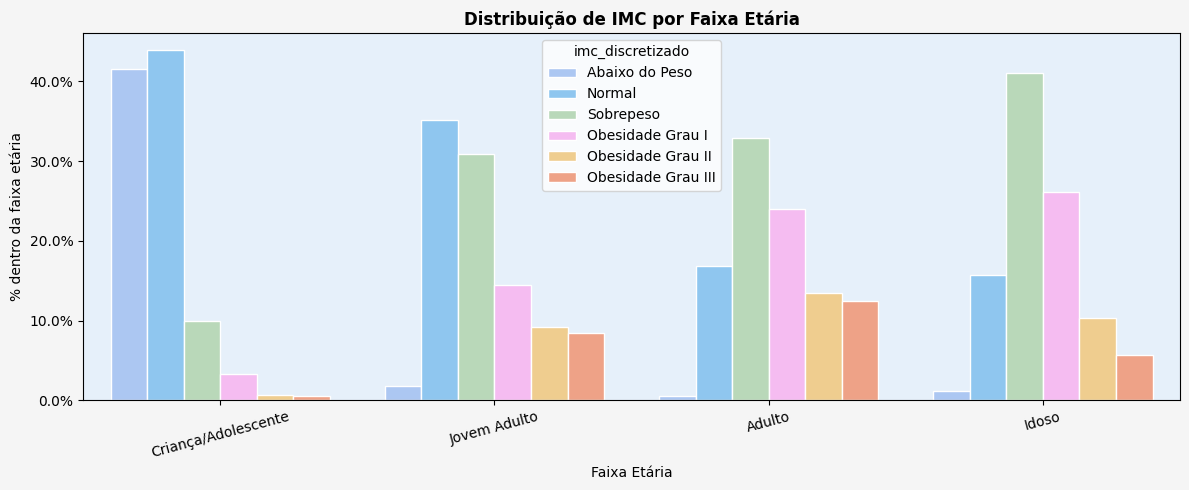

In [23]:
dist_imc_idade = (
    df_subgrupo.groupby(["idade_discretizada", "imc_discretizado"], observed=True)
    .size()
    .reset_index(name="Contagem")
)

dist_imc_idade["% na Faixa Etária"] = (
    dist_imc_idade["Contagem"]
    / dist_imc_idade.groupby("idade_discretizada", observed=True)["Contagem"].transform("sum")
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 5), facecolor="whitesmoke")

sns.barplot(
    data=dist_imc_idade,
    x="idade_discretizada",
    y="% na Faixa Etária",
    hue="imc_discretizado",
    hue_order=["Abaixo do Peso", "Normal", "Sobrepeso", "Obesidade Grau I", "Obesidade Grau II", "Obesidade Grau III"],
    palette={
        "Abaixo do Peso": "#a1c4fd",
        "Normal": "#7fc8ff",
        "Sobrepeso": "#b4ddb4",
        "Obesidade Grau I": "#ffb2f9",
        "Obesidade Grau II": "#ffd27f",
        "Obesidade Grau III": "#ff9a76",
    },
    edgecolor="white",
    ax=ax,
)

ax.set_title("Distribuição de IMC por Faixa Etária", fontsize=12, fontweight="bold")
ax.set_xlabel("Faixa Etária")
ax.set_ylabel("% dentro da faixa etária")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.set_facecolor("#e6f0fa")
ax.tick_params(axis="x", labelrotation=15)

plt.tight_layout()
plt.show()

Conforme pode ser verificado acima, há uma forte incidência de casos de "Sobrepeso" na faixa de idosos, o que ajuda a explicar o comportamento da análise univariada. Isso indica que, embora seja um fator relevante para a definição dos riscos, essa informação provavelmente precisará ser analisada em conjunto com a idade.

## **3. Transformações na Base de Dados e Pré-Processamento**

### **3.1. Análise do Atributo `fumante`: Categoria "Desconhecido"**

#### **3.1.1. Visualização Geral de Dados**

Como apontado anteriormente, aprox. 30% dos registros possuem o status de tabagismo `Desconhecido`, representando uma forma de dado ausente implícita. Os gráficos abaixo investigam se esses registros se distribuem aleatoriamente ou se há padrão sistemático.

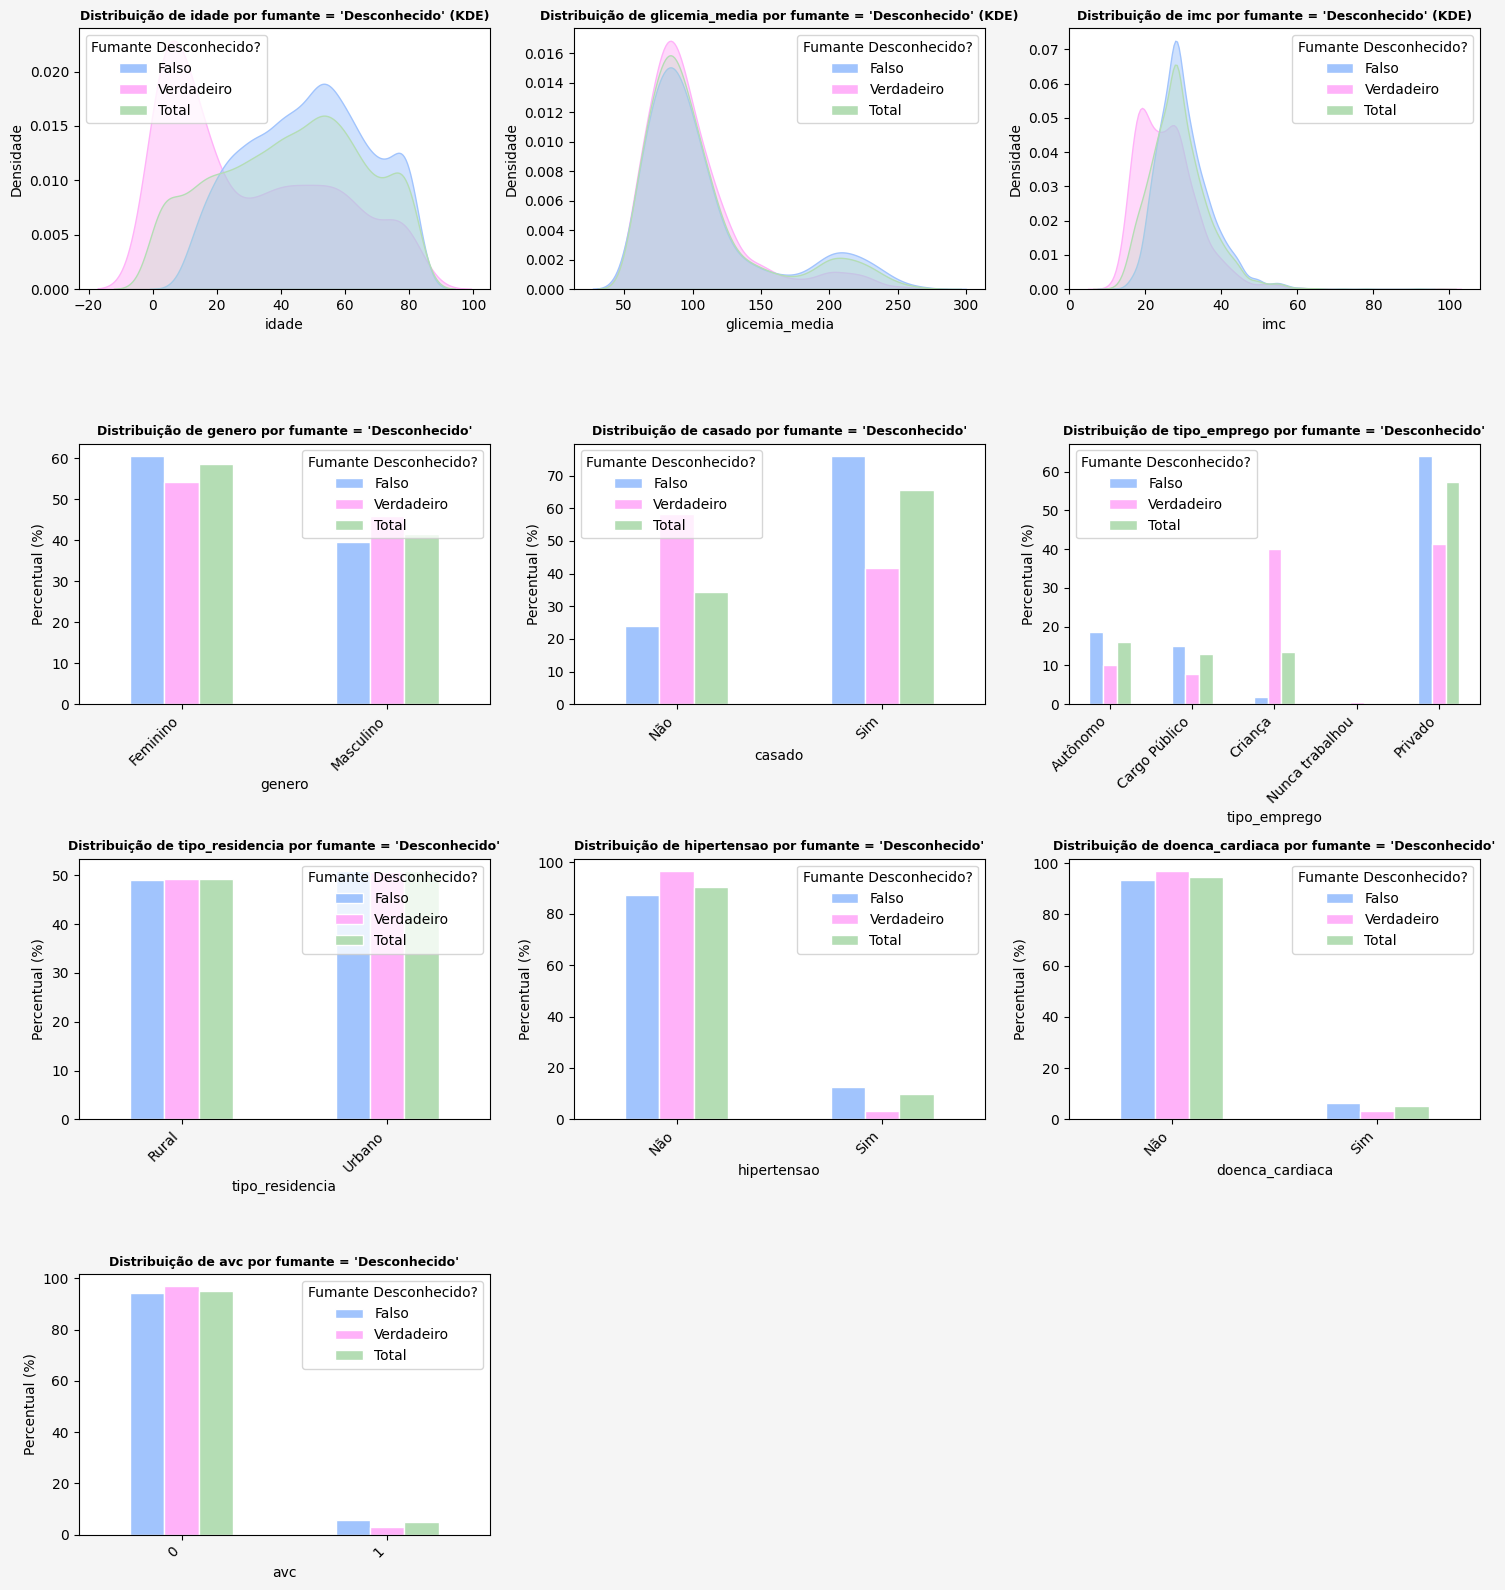

In [24]:
df_avc_exibicao["fumante_desconhecido"] = (
    df_avc["fumante"].eq("Desconhecido").map({False: "Falso", True: "Verdadeiro"})
)

variaveis_num = ["idade", "glicemia_media", "imc"]
variaveis_cat = [
    "genero",
    "casado",
    "tipo_emprego",
    "tipo_residencia",
    "hipertensao",
    "doenca_cardiaca",
    "avc",
]
variaveis_analise = variaveis_num + variaveis_cat

fig, axes = plt.subplots(4, 3, figsize=(15, 16), facecolor="whitesmoke")
axes = axes.flatten()

for ax, var in zip(axes, variaveis_analise):
    if var in variaveis_num:
        # KDE estratificado por flag de desconhecido
        sns.kdeplot(
            data=df_avc_exibicao,
            x=var,
            hue="fumante_desconhecido",
            fill=True,
            common_norm=False,
            palette={"Falso": "#a1c4fd", "Verdadeiro": "#ffb2f9"},
            alpha=0.5,
            ax=ax,
        )
        sns.kdeplot(
            data=df_avc_exibicao,
            x=var,
            fill=True,
            color="#b4ddb4",
            alpha=0.3,
            label="Total",
            ax=ax,
        )
        patches = [
            mpatches.Patch(facecolor="#a1c4fd", edgecolor="white", label="Falso"),
            mpatches.Patch(facecolor="#ffb2f9", edgecolor="white", label="Verdadeiro"),
            mpatches.Patch(facecolor="#b4ddb4", edgecolor="white", label="Total"),
        ]
        ax.legend(handles=patches, title="Fumante Desconhecido?")
        ax.set_title(
            f"Distribuição de {var} por fumante = 'Desconhecido' (KDE)",
            size=9,
            fontweight="bold",
        )
        ax.set_ylabel("Densidade")
    else:
        tabela = (
            pd.crosstab(
                df_avc_exibicao["fumante_desconhecido"],
                df_avc_exibicao[var],
                normalize="index",
            )
            * 100
        )
        total_dist = df_avc_exibicao[var].value_counts(normalize=True) * 100
        tabela.loc["Total"] = total_dist
        tabela.T.plot(
            kind="bar",
            ax=ax,
            color=["#a1c4fd", "#ffb2f9", "#b4ddb4"],
            edgecolor="white",
            rot=45,
        )
        ax.legend(
            title="Fumante Desconhecido?", labels=["Falso", "Verdadeiro", "Total"]
        )
        ax.set_title(
            f"Distribuição de {var} por fumante = 'Desconhecido'",
            size=9,
            fontweight="bold",
        )
        ax.set_ylabel("Percentual (%)")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel(var)

for j in range(len(variaveis_analise), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

A análise gráfica revela um padrão interessante nos registros com status `Desconhecido`. Há uma clara concentração desses registros em menores idades, conforme o gráfico de densidade demonstra. Esse padrão parece ser coerente: para esse grupo, o status de tabagismo frequentemente pode não ser registrado por não ser aplicável.

Para as demais variáveis, não parece haver diferenças relevantes de incidência de AVC nos casos com esse status.

#### **3.1.2. Substituição Parcial da Categoria "Desconhecido"**

Com base no exposto acima, adotou-se a estratégia de substituir os registros com idade menor do que **15 anos** para a instância `Não-fumante`, assumindo por hipótese que seria muito pouco provável que alguém abaixo dessa idade seja fumante.

In [25]:
total_antes = len(df_avc)

# Etapa 1: reclassifica 'Desconhecido' como 'Não-fumante' para pacientes com menos de 15 anos

mask_jovens_desconhecidos = (df_avc["fumante"] == "Desconhecido") & (
    df_avc["idade"] < 15
)
n_reclassificados = mask_jovens_desconhecidos.sum()
df_avc.loc[mask_jovens_desconhecidos, "fumante"] = "Não-fumante"

print(f"Total inicial de registros: {total_antes}")
print(f"Registros reclassificados para 'Não-fumante' (idade < 15): {n_reclassificados}")

Total inicial de registros: 5110
Registros reclassificados para 'Não-fumante' (idade < 15): 614


#### **3.1.3. Verificação de Dados Após a Substituição Parcial**

Após a substituição das instâncias com idade menor do que 15 anos, verificamos novamente a distribuição de casos com dados ausentes implícitos para o atributo `fumante`.

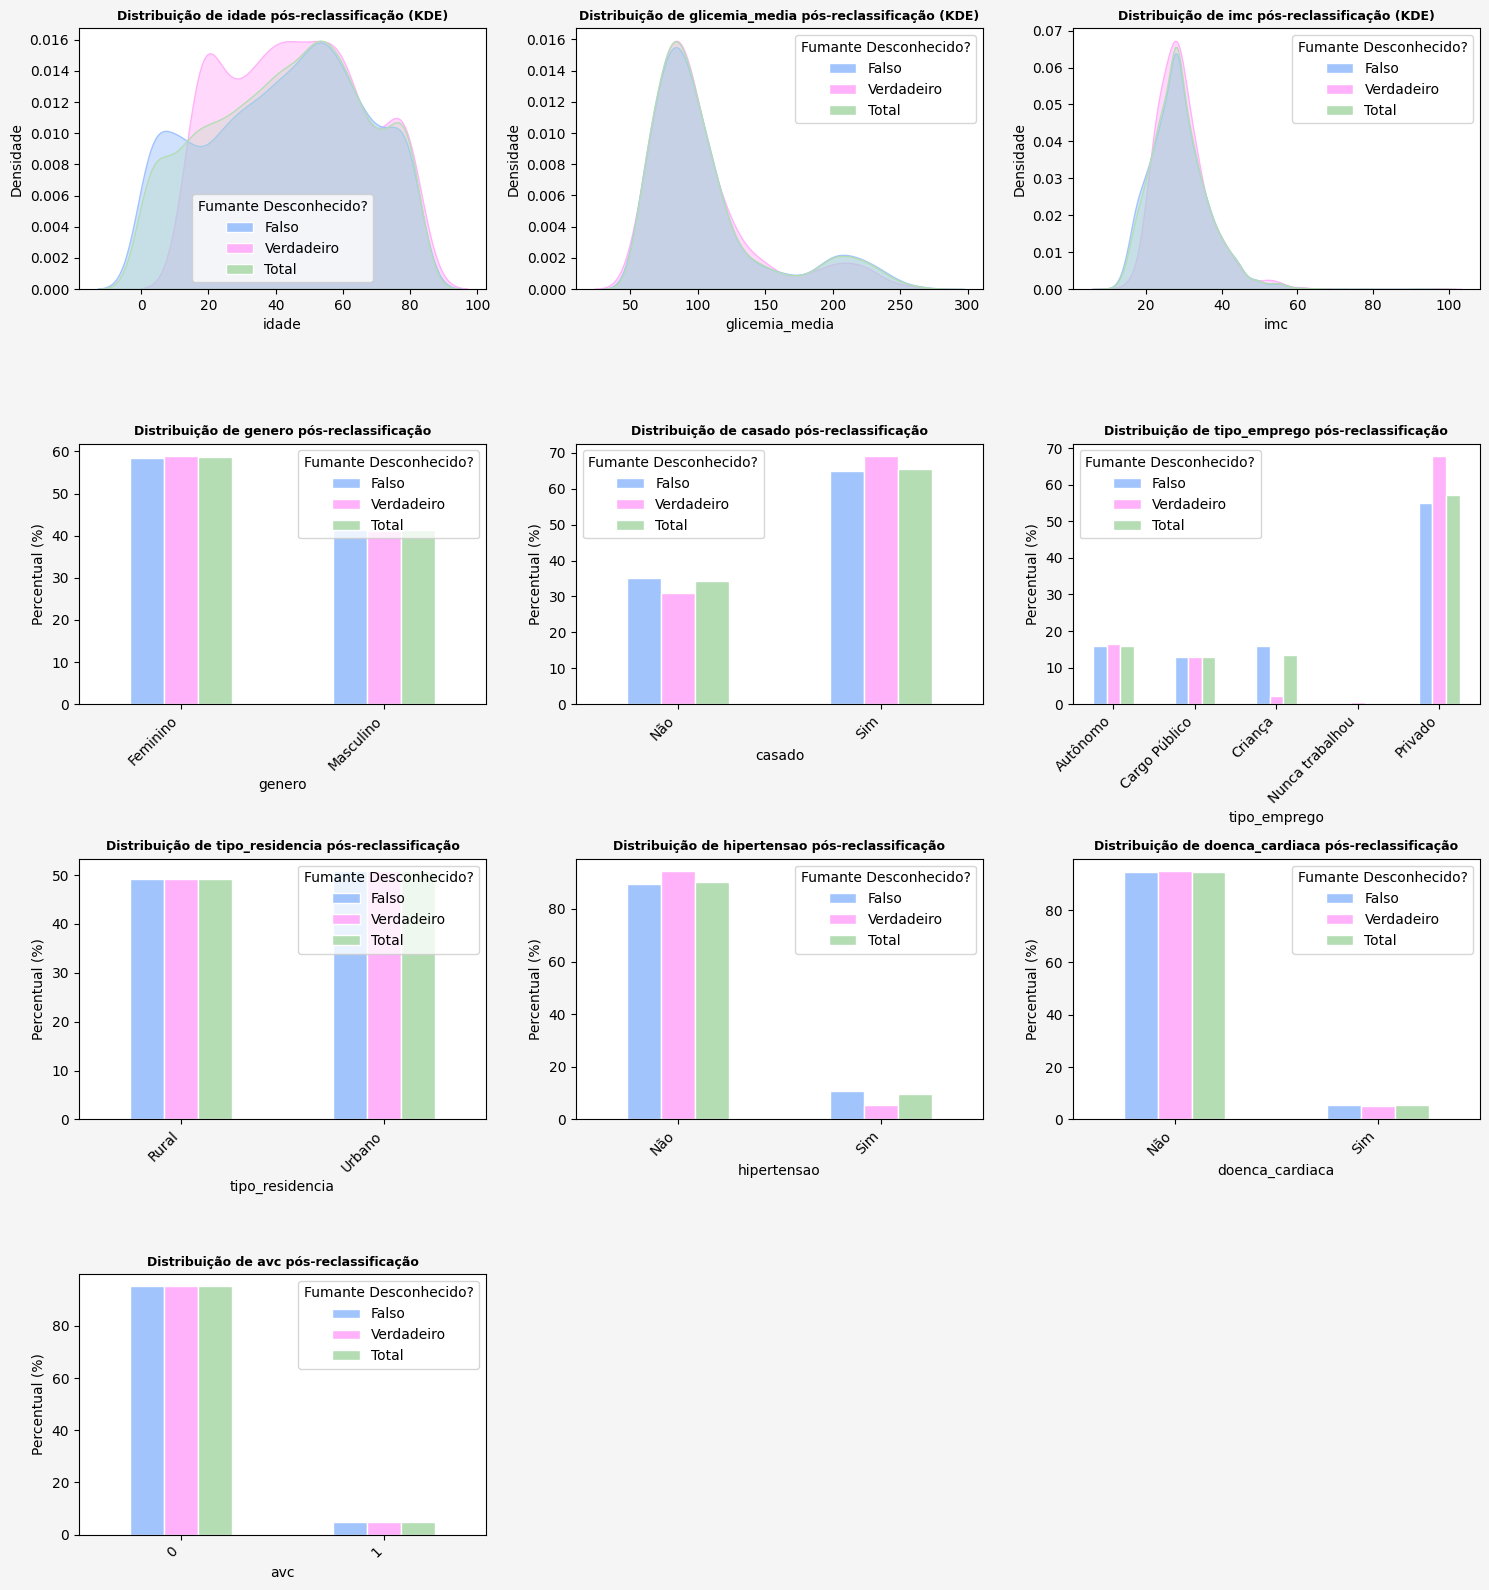

In [26]:
# Recria flag e dataframe de exibição pós-reclassificação para nova visualização

df_avc_exibicao["fumante_desconhecido"] = (
    df_avc["fumante"].eq("Desconhecido").map({False: "Falso", True: "Verdadeiro"})
)

fig, axes = plt.subplots(4, 3, figsize=(15, 16), facecolor="whitesmoke")
axes = axes.flatten()

for ax, var in zip(axes, variaveis_analise):
    if var in variaveis_num:
        sns.kdeplot(
            data=df_avc_exibicao,
            x=var,
            hue="fumante_desconhecido",
            fill=True,
            common_norm=False,
            palette={"Falso": "#a1c4fd", "Verdadeiro": "#ffb2f9"},
            alpha=0.5,
            ax=ax,
        )
        sns.kdeplot(
            data=df_avc_exibicao,
            x=var,
            fill=True,
            color="#b4ddb4",
            alpha=0.3,
            label="Total",
            ax=ax,
        )
        patches = [
            mpatches.Patch(facecolor="#a1c4fd", edgecolor="white", label="Falso"),
            mpatches.Patch(facecolor="#ffb2f9", edgecolor="white", label="Verdadeiro"),
            mpatches.Patch(facecolor="#b4ddb4", edgecolor="white", label="Total"),
        ]
        ax.legend(handles=patches, title="Fumante Desconhecido?")
        ax.set_title(
            f"Distribuição de {var} pós-reclassificação (KDE)",
            size=9,
            fontweight="bold",
        )
        ax.set_ylabel("Densidade")
    else:
        tabela = (
            pd.crosstab(
                df_avc_exibicao["fumante_desconhecido"],
                df_avc_exibicao[var],
                normalize="index",
            )
            * 100
        )
        total_dist = df_avc_exibicao[var].value_counts(normalize=True) * 100
        tabela.loc["Total"] = total_dist
        tabela.T.plot(
            kind="bar",
            ax=ax,
            color=["#a1c4fd", "#ffb2f9", "#b4ddb4"],
            edgecolor="white",
        )
        ax.legend(
            title="Fumante Desconhecido?", labels=["Falso", "Verdadeiro", "Total"]
        )
        ax.set_title(
            f"Distribuição de {var} pós-reclassificação", size=9, fontweight="bold"
        )
        ax.set_ylabel("Percentual (%)")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel(var)

for j in range(len(variaveis_analise), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Após a reclassificação dos registros jovens, a distribuição etária dos desconhecidos remanescentes já não apresenta a concentração em idades baixas observada anteriormente. Os registros restantes com esse status correspondem a adultos para os quais a informação de tabagismo genuinamente não está disponível. Por essa razão, não vemos objeção em descartar os dados no dataframe tratado.

#### **3.1.4. Retirada de Casos Remanescentes da Categoria "Desconhecido"**

In [27]:
# Etapa 2: remove as instâncias 'Desconhecido' remanescentes (adultos sem informação de tabagismo)

n_removidos = (df_avc["fumante"] == "Desconhecido").sum()
df_avc = df_avc[df_avc["fumante"] != "Desconhecido"].reset_index(drop=True)

print(f"Registros removidos (Desconhecido remanescente): {n_removidos}")
print(f"Total final de instâncias: {len(df_avc)}")

Registros removidos (Desconhecido remanescente): 930
Total final de instâncias: 4180


### **3.2. Aplicação da Discretização de Idade, IMC e Glicemia no Dataset Tratado**

Conforme verificamos no item 2.7, a discretização dos atributos numéricos pode trazer insights interessantes a serem utilizados na modelagem. Sendo assim, aplicaremos efetivamente a transformação conforme as categorias definidas no mesmo item.

No entanto, armazenaremos os dados em um dataframe separado, `df_avc_discretizado`, de modo a manter a opção aberta para utilizar os dados categorizados ou não categorizados posteriormente.

In [28]:
df_avc_discretizado = aplicar_discretizacao(df_avc.copy(), CONFIG_DISCRETIZACAO)

print(
    tabulate(
        df_avc_discretizado.head(5).values.tolist(),
        headers=df_avc_discretizado.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_avc_discretizado.columns),
    )
)

╒══════════╤═══════════════╤═══════════════════╤══════════╤════════════════╤═══════════════════╤═════════════╤═══════╤══════════════════════╤════════════════════╤═════════════════════════╕
│  genero  │  hipertensao  │  doenca_cardiaca  │  casado  │  tipo_emprego  │  tipo_residencia  │   fumante   │  avc  │  idade_discretizada  │  imc_discretizado  │  glicemia_discretizado  │
╞══════════╪═══════════════╪═══════════════════╪══════════╪════════════════╪═══════════════════╪═════════════╪═══════╪══════════════════════╪════════════════════╪═════════════════════════╡
│    1     │       0       │         1         │    1     │    Privado     │         1         │ Ex-fumante  │   1   │        Idoso         │ Obesidade Grau II  │        Diabetes         │
├──────────┼───────────────┼───────────────────┼──────────┼────────────────┼───────────────────┼─────────────┼───────┼──────────────────────┼────────────────────┼─────────────────────────┤
│    0     │       0       │         0         │    1  

### **3.3. Retorno à Análise Bivariada - Idade x Fumante**

Uma vez transformados os valores do atributo fumante e da categorização dos dados em df_avc_discretizado, vamos reavaliar a interação do atributo com a variável "idade".

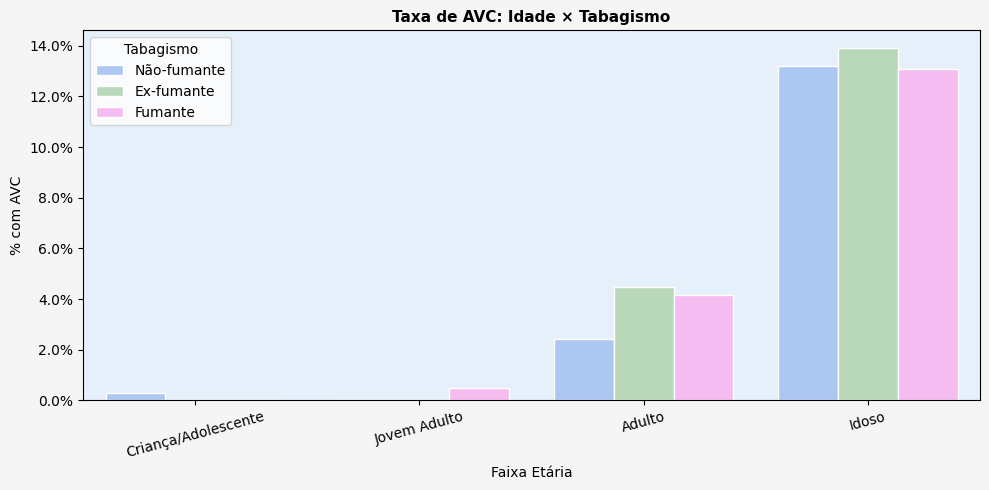

In [29]:
taxa_tabagismo = (
    df_avc_discretizado.groupby(["idade_discretizada", "fumante"], observed=True)["avc"].mean() * 100
).reset_index()
taxa_tabagismo.columns = ["Faixa Etária", "Tabagismo", "Taxa AVC (%)"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor="whitesmoke")

sns.barplot(
    data=taxa_tabagismo,
    x="Faixa Etária",
    y="Taxa AVC (%)",
    hue="Tabagismo",
    hue_order=["Não-fumante", "Ex-fumante", "Fumante"],
    palette={
        "Não-fumante": "#a1c4fd",
        "Ex-fumante": "#b4ddb4",
        "Fumante": "#ffb2f9",
    },
    edgecolor="white",
    ax=ax,
)

ax.set_title("Taxa de AVC: Idade × Tabagismo", fontsize=11, fontweight="bold")
ax.set_ylabel("% com AVC")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.set_facecolor("#e6f0fa")
ax.tick_params(axis="x", labelrotation=15)

plt.tight_layout()
plt.show()

A transformação aplicada na tabela sobre os casos cujo atributo `fumante` é `Desconhecido` não parece ter alterado de maneira significativa as conclusões do item 2.8: as distribuições de categorias desse atributo não parecem apresentar grandes diferenças dentro de cada classe de idade.

### **3.4. Separação em Base de Treino e Teste**

Antes de aplicar qualquer transformação de escala de dados, dividiremos o dataset em conjuntos de treino (80%) e teste (20%). O objetivo da separação prévia é evitar **data leakage**. Se as transformações de escala fossem aplicadas sobre o conjunto completo dos dados, o modelo seria treinado com informações que, em teoria, ele não deveria "conhecer". Utilizou-se, ainda, o parâmetro `stratify=y` para garantir que o desbalanceamento observado anteriormente para a variável resposta seja preservado em ambos os conjuntos.

A separação da base será realizada em dois dataframes distintos:

- `df_avc`: contempla as informações de colunas numéricas contínuas em formato float;

- `df_avc_discretizado`: contempla as informações de colunas numéricas contínuas em formato categórico.

Essa separação reflete os diferentes objetivos que o pré-processamento pretende atingir: para alguns modelos específicos, pode ser interessante trabalhar com o ajuste sobre as variáveis em formato float, enquanto para outros pode ser ideal utilizar a categorização desses atributos. Ao final dessa seção, pretendemos ter datasets em formatos distintos que permitam flexibilidade na posterior seleção do modelo.

Antes de realizar a separação, contudo, é necessário definir quais atributos serão utilizados como preditores. Para isso, retomamos as conclusões da análise exploratória.

#### **3.4.1. Análise das Hipóteses Propostas**

As cinco hipóteses definidas na seção 1.2 foram investigadas ao longo da análise exploratória e do pré-processamento. A seguir, apresentamos um resumo dos principais achados para cada uma delas:

**Hipótese 1 - Confirmada**: A idade é o atributo com maior poder preditivo entre todos os analisados. A correlação point-biserial com a variável resposta `avc` foi de r = 0,25 (p < 0,05), a mais alta entre todos os atributos contínuos, conforme discutido na seção 2.6.4. Os gráficos de densidade (2.6.5) e os box-plots (2.6.6) confirmam que a distribuição dos pacientes com AVC está claramente deslocada para faixas etárias mais avançadas. A análise dos dados discretizados (seção 2.7) reforçou esse entendimento e a análise bivariada (seção 2.8) confirma que a idade amplifica o efeito de todos os demais fatores de risco analisados.

**Hipótese 2 - Confirmada**: Hipertensão e doença cardíaca apresentaram coeficientes phi de φ = 0,13 com `avc` (seção 2.6.4), com taxas de AVC significativamente mais altas para pacientes que apresentam essas comorbidades. A análise bivariada incluindo a faixa etária (seção 2.8) trouxe o entendimento de que o efeito dessas comorbidades é ampliado com o envelhecimento, conforme o crescimento das frequências para faixas etárias mais elevadas.

**Hipótese 3 - Confirmada**: A glicemia média apresentou correlação point-biserial de r = 0,13 e p-valor < 0,05 com a variável resposta `avc` (seção 2.6.4). Para essa hipótese, a análise da discretização trouxe um achado relevante: o limiar clinicamente relevante para a determinação de casos com AVC parece ser o diagnóstico de Diabetes, sem diferença significativa entre a faixa "Normal" e "Pré-diabetes". A análise bivariada da seção 2.8. confirmou que o risco da faixa diabética é mais pronunciado em idosos, reforçando a interação entre os dois fatores.

**Hipótese 4 - Parcialmente confirmada**: Os gráficos de taxa de AVC por categoria (seção 2.6.3) indicam maiores taxas para as categorias de fumantes e ex-fumantes. No entanto, a análise bivariada com a variável faixa etária (seções 2.8 e 3.3) demonstrou que as distribuições das categorias de tabagismo são muito próximas dentro de cada classe de idade. Isso sugere que o tabagismo tem poder preditivo limitado quando a idade é controlada. Por essa razão, considerou-se como parcialmente confirmada: há associação, mas a idade parece ser um preditor mais relevante.

**Hipótese 5 - Parcialmente confirmada**: O IMC apresentou a correlação mais fraca entre os atributos numéricos contínuos (r = 0,05, p < 0,05), conforme discutido na seção 2.6.4. Os gráficos de densidade e box-plots (seções 2.6.5 e 2.6.6) demonstram distribuições muito semelhantes entre pacientes com e sem AVC. A discretização (2.7) trouxe a informação de que a faixa de Sobrepeso apresenta uma taxa superior às faixas de obesidade, o que representa um comportamento irregular que é, em parte, explicado na seção 2.8: a concentração de casos na faixa de Sobrepeso está fortemente associada à faixa de idosos, sugerindo interação com a idade. O IMC parece ter um papel secundário na predição de `avc`, mas entendemos o atributo como ainda relevante para a modelagem.

#### **3.4.2. Remoção de Atributos com Baixo Valor Preditivo**

Com base nos achados acima, optou-se por remover as seguintes variáveis dos conjuntos de treino e teste antes da modelagem, tanto no `df_avc` quanto no `df_avc_discretizado`:

- **`genero`:** Correlação phi praticamente nula com `avc` (φ = 0,00, seção 2.6.4) e ausência de diferença expressiva entre categorias nos gráficos de taxa de AVC (seção 2.6.3), indicando poder preditivo baixo;

- **`tipo_residencia`:** Comportamento muito semelhante ao de `genero`, com φ = 0,01 e distribuições praticamente indistintas entre as classes (seções 2.6.3 e 2.6.4);

- **`casado`:** Embora apresente correlação phi de φ = 0,11 com `avc`, essa associação é provavelmente intermediada pela variável `idade`, dado que `casado` × `idade` apresentou a correlação mais alta da matriz (r = 0,69, seção 2.6.4). Manter `casado` como preditor introduziria redundância em relação à `idade` sem acrescentar poder discriminativo independente;

- **`tipo_emprego`:** A análise dos gráficos de taxa de AVC (seção 2.6.3) mostrou que as diferenças entre categorias são explicadas majoritariamente pela faixa etária associada a cada tipo de emprego. Em particular, a categoria `Criança` tem taxa nula por razões de idade, não de vínculo empregatício. A variável não adiciona informação clínica relevante de forma independente.

In [30]:
X = df_avc.drop(columns=["avc", "genero", "casado", "tipo_emprego", "tipo_residencia"])
y = df_avc["avc"]

X_discretizado = df_avc_discretizado.drop(
    columns=["avc", "genero", "casado", "tipo_emprego", "tipo_residencia"]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_discretizado = X_discretizado.loc[X_train.index]
X_test_discretizado = X_discretizado.loc[X_test.index]

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} registros")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} registros")
print(f"\nProporção de AVC no treino: {y_train.mean():.2%}")
print(f"Proporção de AVC no teste:  {y_test.mean():.2%}")

Tamanho do conjunto de treino: 3344 registros
Tamanho do conjunto de teste:  836 registros

Proporção de AVC no treino: 4.87%
Proporção de AVC no teste:  4.90%


### **3.5. One-Hot Encoding**

Após a separação entre treino e teste para ambos os dataframes, aplicaremos a transformação One-Hot Encoding sobre os atributos categóricos, o que pode ser útil para alguns modelos. Cabe mencionar, contudo, que a aplicação direta pode incluir redundância. Como somente uma das categorias pode estar associada a cada instância, podemos reduzir a dimensionalidade da tabela transformada ao omitir uma das categorias. Utilizou-se o parâmetro `drop="first"` para atingir esse objetivo.

De forma semelhante ao realizado para a separação dos dados de treino e teste, o One-Hot Encoding será aplicado separadamente para os dataframes com e sem a categorização das colunas numéricas contínuas. É necessário atentar para o fato de que esses dataframes aplicarão a transformação sobre atributos distintos:

-  `fumante`: presente em todos os dataframes;

- `idade_discretizada`, `imc_discretizado` e `glicemia_discretizado`: presentes somente nos dataframes discretizados.

In [31]:
def aplicar_ohe(X_train, X_test, colunas_ohe):
    ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

    colunas_encoded = ohe.fit_transform(X_train[colunas_ohe])
    colunas_names = ohe.get_feature_names_out(colunas_ohe)
    colunas_restantes = [c for c in X_train.columns if c not in colunas_ohe]

    X_train_ohe = pd.concat(
        [
            X_train[colunas_restantes].reset_index(drop=True),
            pd.DataFrame(colunas_encoded, columns=colunas_names),
        ],
        axis=1,
    )
    X_test_ohe = pd.concat(
        [
            X_test[colunas_restantes].reset_index(drop=True),
            pd.DataFrame(ohe.transform(X_test[colunas_ohe]), columns=colunas_names),
        ],
        axis=1,
    )
    return X_train_ohe, X_test_ohe


COLUNAS_OHE_DISCRETIZADO = [
    "fumante",
    "idade_discretizada",
    "imc_discretizado",
    "glicemia_discretizado",
]

X_train_ohe, X_test_ohe = aplicar_ohe(X_train, X_test, ["fumante"])
X_train_discretizado_ohe, X_test_discretizado_ohe = aplicar_ohe(
    X_train_discretizado, X_test_discretizado, COLUNAS_OHE_DISCRETIZADO
)

print("=== Primeiras 5 linhas: dataframe 'X_train_ohe' (sem discretização) ===\n")
print(
    tabulate(
        X_train_ohe.head(5).values.tolist(),
        headers=X_train_ohe.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(X_train_ohe.columns),
    )
)

print(
    "\n\n=== Primeiras 5 linhas: dataframe 'X_train_discretizado_ohe' (com discretização) ===\n"
)
print(
    tabulate(
        X_train_discretizado_ohe.head(5).values.tolist(),
        headers=X_train_discretizado_ohe.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(X_train_discretizado_ohe.columns),
    )
)

=== Primeiras 5 linhas: dataframe 'X_train_ohe' (sem discretização) ===

╒═════════╤═══════════════╤═══════════════════╤══════════════════╤═══════╤═══════════════════╤═══════════════════════╕
│  idade  │  hipertensao  │  doenca_cardiaca  │  glicemia_media  │  imc  │  fumante_Fumante  │  fumante_Não-fumante  │
╞═════════╪═══════════════╪═══════════════════╪══════════════════╪═══════╪═══════════════════╪═══════════════════════╡
│   45    │       0       │         0         │      106.83      │ 32.1  │         0         │           0           │
├─────────┼───────────────┼───────────────────┼──────────────────┼───────┼───────────────────┼───────────────────────┤
│   50    │       1       │         0         │      220.36      │ 40.9  │         0         │           0           │
├─────────┼───────────────┼───────────────────┼──────────────────┼───────┼───────────────────┼───────────────────────┤
│   67    │       0       │         0         │      238.78      │ 35.7  │         0         │

### **3.6. Normalização (Min-Max) e Padronização (Z-Score)**

Adicionalmente às transformações realizadas, para alguns modelos pode ser de interesse trabalhar com a normalização ou a padronização das colunas numéricas contínuas (`idade`, `glicemia_media` e `imc`). Essas transformações atuam exclusivamente sobre a escala dos dados, sem alterar sua distribuição ou a relação entre as observações.

- **Normalização Min-Max:** Reescala os valores para o intervalo [0, 1] com base no mínimo e no máximo observados. É preferível quando se deseja preservar a distribuição original dos dados e quando o modelo é sensível à magnitude absoluta dos valores;

- **Padronização Z-Score:** Transforma os valores para que tenham média 0 e desvio-padrão 1. É preferível quando os dados apresentam outliers relevantes (como verificado nos box-plots da seção 2.6.6) pois não é limitada por valores extremos da mesma forma que o Min-Max.

Em ambos os casos, os parâmetros de transformação são ajustados exclusivamente sobre os dados de treino (`fit_transform`) e apenas aplicados ao conjunto de teste (`transform`), prevenindo vazamento de informação conforme discutido na seção 3.4.

In [32]:
colunas_escalar = [c for c in COLUNAS_CONTINUAS if c in X_train_ohe.columns]


def aplicar_escalonamento(scaler, X_train_base, X_test_base, colunas):
    X_train_scaled = X_train_base.copy()
    X_test_scaled = X_test_base.copy()
    X_train_scaled[colunas] = scaler.fit_transform(X_train_base[colunas])
    X_test_scaled[colunas] = scaler.transform(X_test_base[colunas])
    return X_train_scaled, X_test_scaled


X_train_minmax, X_test_minmax = aplicar_escalonamento(
    MinMaxScaler(), X_train_ohe, X_test_ohe, colunas_escalar
)
X_train_zscore, X_test_zscore = aplicar_escalonamento(
    StandardScaler(), X_train_ohe, X_test_ohe, colunas_escalar
)

print("=== Comparativo: Treino Original vs. Normalizado vs. Padronizado ===\n")
for col in colunas_escalar:
    df_comp = pd.DataFrame(
        {
            "Métrica": ["Mínimo", "Máximo", "Média", "Desvio-Padrão"],
            "Treino Original": [
                round(X_train_ohe[col].min(), 3),
                round(X_train_ohe[col].max(), 3),
                round(X_train_ohe[col].mean(), 3),
                round(X_train_ohe[col].std(), 3),
            ],
            "Treino Normalizado (Min-Max)": [
                round(X_train_minmax[col].min(), 3),
                round(X_train_minmax[col].max(), 3),
                round(X_train_minmax[col].mean(), 3),
                round(X_train_minmax[col].std(), 3),
            ],
            "Treino Padronizado (Z-Score)": [
                round(X_train_zscore[col].min(), 3),
                round(X_train_zscore[col].max(), 3),
                round(X_train_zscore[col].mean(), 3),
                round(X_train_zscore[col].std(), 3),
            ],
        }
    )
    print(f"Atributo: {col}")
    print(
        tabulate(
            df_comp.values.tolist(),
            headers=df_comp.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * len(df_comp.columns),
        )
    )
    print()

print("\n\n=== Primeiras 5 linhas: X_train_minmax (Normalizado - Min-Max) ===\n")
print(
    tabulate(
        X_train_minmax.head(5).values.tolist(),
        headers=X_train_minmax.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(X_train_minmax.columns),
    )
)

print("\n\n=== Primeiras 5 linhas: X_train_zscore (Padronizado - Z-Score) ===\n")
print(
    tabulate(
        X_train_zscore.head(5).values.tolist(),
        headers=X_train_zscore.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(X_train_zscore.columns),
    )
)

=== Comparativo: Treino Original vs. Normalizado vs. Padronizado ===

Atributo: idade
╒═══════════════╤═══════════════════╤════════════════════════════════╤════════════════════════════════╕
│    Métrica    │  Treino Original  │  Treino Normalizado (Min-Max)  │  Treino Padronizado (Z-Score)  │
╞═══════════════╪═══════════════════╪════════════════════════════════╪════════════════════════════════╡
│    Mínimo     │       0.16        │               0                │             -1.835             │
├───────────────┼───────────────────┼────────────────────────────────┼────────────────────────────────┤
│    Máximo     │        82         │               1                │             1.704              │
├───────────────┼───────────────────┼────────────────────────────────┼────────────────────────────────┤
│     Média     │      42.598       │             0.519              │               -0               │
├───────────────┼───────────────────┼────────────────────────────────┼────────────

A tabela comparativa confirma o comportamento esperado de cada transformação:

- **Min-Max:** valores reescalados entre 0 e 1, com a forma da distribuição original preservada;

- **Z-Score:** média converge para 0 e desvio-padrão para 1, facilitando a interpretação de coeficientes em modelos lineares. Vale notar que o IMC padronizado apresenta máximo de 8,177, o que indica que algum valor está a pelo menos 8 desvios-padrões longe da média, valor bem distante do centro. Isso ocorre em decorrência do fato de que o Z-Score não elimina o efeito de valores extremos (como vimos existir para a variável `imc` nos box-plots da seção 2.6.6), apenas os reescalona.

### **3.7. Balanceamento de Classes com SMOTE**

O forte desbalanceamento identificado da variável resposta (aprox. 4,9% de casos positivos) pode comprometer o aprendizado dos modelos preditivos, que tendem a favorecer a classe majoritária. Desse modo, optou-se por aplicar o SMOTE, que gera instâncias sintéticas da classe minoritária por meio da interpolação entre vizinhos próximos no espaço de atributos.

O SMOTE é aplicado somente sobre o conjunto de treino. Desse modo, a distribuição real do teste é preservada, o que é essencial para que as métricas de avaliação reflitam o desempenho esperado sobre dados com o desbalanceamento natural do problema.

In [33]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_ohe, y_train)
X_train_minmax_smote, _ = smote.fit_resample(X_train_minmax, y_train)
X_train_zscore_smote, _ = smote.fit_resample(X_train_zscore, y_train)
X_train_discretizado_smote, _ = smote.fit_resample(X_train_discretizado_ohe, y_train)

dist_antes = y_train.value_counts().sort_index()
dist_depois = pd.Series(y_train_smote).value_counts().sort_index()

df_comp_smote = pd.DataFrame(
    {
        "Classe": ["Sem AVC (0)", "Com AVC (1)"],
        "Treino Original": dist_antes.values,
        "% Original": (dist_antes / dist_antes.sum() * 100).round(1).values,
        "Treino com SMOTE": dist_depois.values,
        "% com SMOTE": (dist_depois / dist_depois.sum() * 100).round(1).values,
    }
)

print("=== Distribuição da variável-resposta: antes e depois do SMOTE ===\n")
print(
    tabulate(
        df_comp_smote.values.tolist(),
        headers=df_comp_smote.columns.tolist(),
        tablefmt="fancy_grid",
        colalign=["center"] * len(df_comp_smote.columns),
    )
)

for nome, df in [
    ("X_train_smote (OHE)", pd.DataFrame(X_train_smote, columns=X_train_ohe.columns)),
    (
        "X_train_minmax_smote (OHE + Min-Max)",
        pd.DataFrame(X_train_minmax_smote, columns=X_train_minmax.columns),
    ),
    (
        "X_train_zscore_smote (OHE + Z-Score)",
        pd.DataFrame(X_train_zscore_smote, columns=X_train_zscore.columns),
    ),
    (
        "X_train_discretizado_smote (Discretizado + OHE)",
        pd.DataFrame(
            X_train_discretizado_smote, columns=X_train_discretizado_ohe.columns
        ),
    ),
]:
    print(f"\n\n=== Primeiras 5 linhas: {nome} ===\n")
    print(
        tabulate(
            df.head(5).values.tolist(),
            headers=df.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * len(df.columns),
        )
    )

=== Distribuição da variável-resposta: antes e depois do SMOTE ===

╒═════════════╤═══════════════════╤══════════════╤════════════════════╤═══════════════╕
│   Classe    │  Treino Original  │  % Original  │  Treino com SMOTE  │  % com SMOTE  │
╞═════════════╪═══════════════════╪══════════════╪════════════════════╪═══════════════╡
│ Sem AVC (0) │       3181        │     95.1     │        3181        │      50       │
├─────────────┼───────────────────┼──────────────┼────────────────────┼───────────────┤
│ Com AVC (1) │        163        │     4.9      │        3181        │      50       │
╘═════════════╧═══════════════════╧══════════════╧════════════════════╧═══════════════╛


=== Primeiras 5 linhas: X_train_smote (OHE) ===

╒═════════╤═══════════════╤═══════════════════╤══════════════════╤═══════╤═══════════════════╤═══════════════════════╕
│  idade  │  hipertensao  │  doenca_cardiaca  │  glicemia_media  │  imc  │  fumante_Fumante  │  fumante_Não-fumante  │
╞═════════╪═══════════════╪

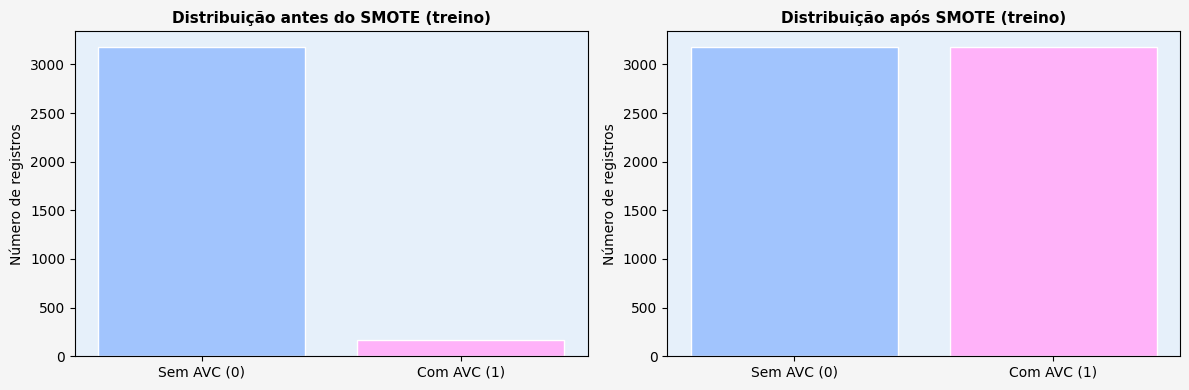

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="whitesmoke")
cores_barras = ["#a1c4fd", "#ffb2f9"]
rotulos_classes = ["Sem AVC (0)", "Com AVC (1)"]

for ax, dist, titulo in [
    (axes[0], dist_antes, "Distribuição antes do SMOTE (treino)"),
    (axes[1], dist_depois, "Distribuição após SMOTE (treino)"),
]:
    ax.bar(rotulos_classes, dist.values, color=cores_barras, edgecolor="white")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_ylabel("Número de registros")
    ax.set_facecolor("#e6f0fa")

plt.tight_layout()
plt.show()

O gráfico confirma que o SMOTE equiparou as classes no conjunto de treino, gerando amostras sintéticas da classe minoritária até atingir o mesmo volume da classe majoritária. Como esperado, o conjunto de teste permanece inalterado, com a distribuição real (4,9% de AVC), garantindo uma avaliação de desempenho realista na etapa de modelagem.

### **3.8. Verificação das Amostras Sintéticas do SMOTE**

O SMOTE gera amostras sintéticas por interpolação entre instâncias reais da classe minoritária. É boa prática verificar se os valores gerados são clinicamente plausíveis. A seguir, verificaremos se os valores contínuos gerados estão dentro de intervalos plausíveis e se as proporções dos atributos categóricos foram preservadas.

In [35]:
variaveis_originais_ohe = {
    "hipertensao": ["hipertensao"],
    "doenca_cardiaca": ["doenca_cardiaca"],
    **{
        prefixo: [c for c in X_train_ohe.columns if c.startswith(prefixo + "_")]
        for prefixo in ["fumante"]
    },
}

variaveis_originais_disc = {
    "hipertensao": ["hipertensao"],
    "doenca_cardiaca": ["doenca_cardiaca"],
    **{
        prefixo: [
            c for c in X_train_discretizado_ohe.columns if c.startswith(prefixo + "_")
        ]
        for prefixo in [
            "fumante",
            "idade_discretizada",
            "imc_discretizado",
            "glicemia_discretizado",
        ]
    },
}

n_original_train = len(X_train_ohe)
df_sintetico = pd.DataFrame(X_train_smote, columns=X_train_ohe.columns).iloc[
    n_original_train:
]

df_sintetico_resumo = (
    df_sintetico[colunas_escalar].agg(["min", "max", "mean", "std"]).round(3)
)
df_sintetico_resumo = df_sintetico_resumo.rename(
    index={"min": "mínimo", "max": "máximo", "mean": "média", "std": "desvio-padrão"}
)

print(
    "=== Estatísticas das amostras sintéticas geradas pelo SMOTE (atributos contínuos) ==="
)
print(
    tabulate(
        df_sintetico_resumo.reset_index().values.tolist(),
        headers=["métrica"] + colunas_escalar,
        tablefmt="fancy_grid",
        colalign=["center"] * (len(colunas_escalar) + 1),
    )
)

print("\n=== Verificação de valores impossíveis nas amostras sintéticas ===")
invalidos = {
    "imc": (df_sintetico["imc"] <= 0).sum(),
    "glicemia_media": (df_sintetico["glicemia_media"] <= 0).sum(),
    "idade": (df_sintetico["idade"] < 0).sum(),
}
for atributo, n_inv in invalidos.items():
    status = "Nenhum valor impossível" if n_inv == 0 else f"{n_inv} registros inválidos"
    print(f"  {atributo}: {status}")

n_original_disc = len(X_train_discretizado_ohe)
df_sintetico_disc = pd.DataFrame(
    X_train_discretizado_smote, columns=X_train_discretizado_ohe.columns
).iloc[n_original_disc:]

for titulo, df_orig, df_sint, variaveis in [
    (
        "Proporções das amostras sintéticas vs. Treino Original (base não discretizada)",
        X_train_ohe,
        df_sintetico,
        variaveis_originais_ohe,
    ),
    (
        "Proporções das amostras sintéticas vs. Treino Original (base discretizada)",
        X_train_discretizado_ohe,
        df_sintetico_disc,
        variaveis_originais_disc,
    ),
]:
    linhas = []
    for variavel, colunas in variaveis.items():
        for col in colunas:
            label = col.replace(f"{variavel}_", "") if "_" in col else "= 1"
            prop_orig = df_orig[col].mean() * 100
            prop_sint = df_sint[col].mean() * 100
            linhas.append(
                [
                    variavel,
                    label,
                    f"{prop_orig:.1f}%",
                    f"{prop_sint:.1f}%",
                    f"{prop_sint - prop_orig:+.1f}p.p.",
                ]
            )

    df_verificacao = pd.DataFrame(
        linhas,
        columns=[
            "Variável",
            "Categoria",
            "Treino Original",
            "Amostras Sintéticas",
            "Δ",
        ],
    )

    print(f"\n\n=== {titulo} ===\n")
    print(
        tabulate(
            df_verificacao.values.tolist(),
            headers=df_verificacao.columns.tolist(),
            tablefmt="fancy_grid",
            colalign=["center"] * len(df_verificacao.columns),
        )
    )

=== Estatísticas das amostras sintéticas geradas pelo SMOTE (atributos contínuos) ===
╒═══════════════╤═════════╤══════════════════╤════════╕
│    métrica    │  idade  │  glicemia_media  │  imc   │
╞═══════════════╪═════════╪══════════════════╪════════╡
│    mínimo     │ 15.174  │      56.11       │ 17.386 │
├───────────────┼─────────┼──────────────────┼────────┤
│    máximo     │   82    │     271.597      │ 47.334 │
├───────────────┼─────────┼──────────────────┼────────┤
│     média     │ 68.687  │     133.203      │ 30.472 │
├───────────────┼─────────┼──────────────────┼────────┤
│ desvio-padrão │ 11.162  │      62.422      │ 4.808  │
╘═══════════════╧═════════╧══════════════════╧════════╛

=== Verificação de valores impossíveis nas amostras sintéticas ===
  imc: Nenhum valor impossível
  glicemia_media: Nenhum valor impossível
  idade: Nenhum valor impossível


=== Proporções das amostras sintéticas vs. Treino Original (base não discretizada) ===

╒═════════════════╤═══════════════

As estatísticas dos atributos contínuos nas amostras sintéticas revelam um perfil condizente com o esperado: idade média de 68,7 anos, glicemia média de 133,2 e IMC médio de 30,5, valores que concentram as amostras sintéticas no perfil de maior risco clínico, conforme discutido na Análise Exploratória. Nenhum valor impossível clinicamente foi identificado.

A análise das proporções categóricas, por sua vez, confirma o padrão observado anteriormente. Como as amostras são geradas exclusivamente por interpolação de casos positivos, é esperado que os desvios afetem as categorias de maior risco:

- **Idade Discretizada**: 78,1% das amostras sintéticas pertencem à faixa `Idoso` (+51,4 p.p), enquanto "Criança/Adolescente" e "Jovem Adulto" praticamente desaparecem (0,3% e 0,4%, respectivamente). Isso é esperado, dado que o AVC é raro nessas faixas. O SMOTE não encontra "vizinhos" positivos para interpolar;

- **Glicemia Discretizada**: Tanto as categorias `Normal` quanto `Pré-diabetes` são reduzidas, de modo a reforçar que o quadro diabético é o mais significativo para a previsão de casos de AVC;

- **IMC Discretizado**: Aumento significativo da proporção de casos de `Sobrepeso` (+11,8 p.p), classe já identificada como mais agravada anteriormente.

- **Tabagismo**: Enquanto a categoria `Fumante` sofre pequenos aumentos em ambos os conjuntos, a proporção de `Não-fumantes` é reduzida (17,7 p.p no conjunto categorizado e 18,8 p.p no conjunto não categorizado), comportamento condizente com a Análise Exploratória;

- **Hipertensão**: Para esse atributo, o impacto foi bem diferente para ambos os conjuntos de dados: no conjunto não discretizado, o crescimento é de apenas 0,2 p.p., enquanto no conjunto discretizado o crescimento é de 15,9 p.p. Uma possível explicação é a própria discretização do campo `idade`. Como os idosos concentram a maioria das amostras sintéticas, o SMOTE interpola em um espaço onde a hipertensão é mais prevalente, pois a comorbidade é mais comum em pacientes mais velhos. No conjunto não categorizado, a idade entra como uma variável numérica contínua e o efeito de concentração é diluído;

- **Doença Cardíaca**: O mesmo raciocínio se aplica: o impacto é menor no conjunto não discretizado, mas ainda apresenta comportamento conforme a expectativa no conjunto discretizado.

Em resumo, os desvios não indicam falhas no processo, mas o comportamento esperado das variáveis conforme o perfil da Análise Exploratória de cada atributo. O treino balanceado passa a sobrerrepresentar categorias relevantes à predição da variável-resposta.

## **4. Datasets finais**

Após a aplicação das etapas de pré-processamento sobre os dados, os seguintes conjuntos de dados estão disponíveis para modelagem:

### **4.1. Conjuntos de Treino**

| Dataframe | Transformações |
|:---|:---|
| `X_train_ohe` | OHE sobre `fumante`, mantendo as variáveis numéricas contínuas |
| `X_train_minmax` | OHE sobre `fumante`, contemplando a Normalização Min-Max para as variáveis numéricas contínuas |
| `X_train_zscore` | OHE sobre `fumante`, contemplando a Padronização Z-Score para as variáveis numéricas contínuas |
| `X_train_discretizado_ohe` | OHE sobre `fumante`, `idade_discretizada`, `glicemia_discretizado` e `imc_discretizado` |
| `X_train_smote` | OHE sobre `fumante`, mantendo as variáveis numéricas contínuas e aplicando SMOTE |
| `X_train_minmax_smote` | OHE sobre `fumante`, contemplando a Normalização Min-Max para as variáveis numéricas contínuas e aplicando SMOTE |
| `X_train_zscore_smote` | OHE sobre `fumante`, contemplando a Padronização Z-Score para as variáveis numéricas contínuas e aplicando SMOTE |
| `X_train_discretizado_smote` | OHE sobre `fumante`, `idade_discretizada`, `glicemia_discretizado` e `imc_discretizado` e aplicando SMOTE |

### **4.2. Conjuntos de Teste**

| Dataframe | Transformações |
|:---|:---|
| `X_test_ohe` | OHE sobre `fumante`, mantendo as variáveis numéricas contínuas |
| `X_test_minmax` | OHE sobre `fumante`, contemplando a Normalização Min-Max para as variáveis numéricas contínuas |
| `X_test_zscore` | OHE sobre `fumante`, contemplando a Padronização Z-Score para as variáveis numéricas contínuas |
| `X_test_discretizado_ohe` | OHE sobre `fumante`, `idade_discretizada`, `glicemia_discretizado` e `imc_discretizado` |

### **4.3. Variáveis-Resposta**

| Dataframe | Descrição |
|:---|:---|
| `y_train` | Variável-resposta do conjunto de treino |
| `y_train_smote` | Variável-resposta do conjunto de treino após SMOTE |
| `y_test` | Variável-resposta do conjunto de teste |